<a href="https://colab.research.google.com/github/rismawidiyanti/skipgram-news-experiment/blob/main/Tugas_Word2Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim nltk newsapi-python

In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

In [ ]:
# Download NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Konfigurasi API Key
NEWS_API_KEY = "3ad8deb6cd0f4cfb9cb1747057f34e78"
NEWS_API_ENDPOINT = "https://newsapi.org/v2/everything"

In [ ]:
# Fungsi untuk mengambil data berita
def fetch_news(query, language='en', page_size=100):
    params = {'q': query, 'apiKey': NEWS_API_KEY, 'language': language, 'pageSize': page_size}
    response = requests.get(NEWS_API_ENDPOINT, params=params)

    if response.status_code == 200:
        return response.json()
    print(f"Error: {response.status_code}")
    return None

# Daftar kata kunci untuk query
queries = ["technology", "politics", "business", "science", "health", "sports", "entertainment",
           "education", "environment", "finance", "medicine", "innovation", "artificial intelligence",
           "climate change", "space exploration", "bitcoin", "olympics", "COVID"]

# Mengambil dan memproses berita untuk setiap query
all_articles = []
for query in queries:
    news_data = fetch_news(query=query)
    if news_data and 'articles' in news_data:
        for article in news_data['articles']:
            if article.get('title') and article.get('description'):
                all_articles.append({'title': article['title'], 'description': article['description']})

# Membuat DataFrame
df = pd.DataFrame(all_articles)
print(f"Jumlah artikel: {len(df)}")
print(df.head())

Jumlah artikel: 1675
                                               title  \
0  Grid-Scale Battery Storage Is Quietly Revoluti...   
1  The Verge is nominated for two Webby Awards — ...   
2  Firefly’s Alpha Rocket Crashes Into Pacific Oc...   
3  PM Modi and Elon Musk talk India-US tech colla...   
4                                Fun With Technology   

                                         description  
0  This energy storage technology is harnessing t...  
1  The time of year has arrived â Webby Award s...  
2  The failure resulted in the loss of a Lockheed...  
3  Modi said he discussed with Musk India's poten...  
4  The power of makers and making is in battling ...  


In [ ]:
# Fungsi preprocessing teks
def preprocess_text(text):
    if not isinstance(text, str):
        return []

    # Mengubah ke lowercase
    text = text.lower()

    # Menghapus tanda baca
    text = re.sub(f'[{string.punctuation}]', ' ', text)

    # Menghapus angka
    text = re.sub(r'\d+', '', text)

    # Tokenisasi
    tokens = word_tokenize(text)

    # Menghapus stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    return tokens

# Menggabungkan judul dan deskripsi untuk preprocessing
df['text'] = df['title'] + ' ' + df['description']

# Preprocessing teks
df['tokens'] = df['text'].apply(preprocess_text)

# Menghapus artikel tanpa token
df = df[df['tokens'].map(len) > 0]

# Menampilkan contoh hasil preprocessing
print(f"Jumlah artikel setelah preprocessing: {len(df)}")
print("\nContoh hasil preprocessing:")
for i in range(min(3, len(df))):
    print(f"\nArticle {i+1}:")
    print(f"Original: {df.iloc[i]['text'][:100]}...")
    print(f"Tokens: {df.iloc[i]['tokens'][:15]}...")

Jumlah artikel setelah preprocessing: 1675

Contoh hasil preprocessing:

Article 1:
Original: Grid-Scale Battery Storage Is Quietly Revolutionizing the Energy System This energy storage technolo...
Tokens: ['grid', 'scale', 'battery', 'storage', 'quietly', 'revolutionizing', 'energy', 'system', 'energy', 'storage', 'technology', 'harnessing', 'potential', 'solar', 'wind']...

Article 2:
Original: The Verge is nominated for two Webby Awards — help us win them! The time of year has arrived â Web...
Tokens: ['verge', 'nominated', 'two', 'webby', 'awards', 'help', 'win', 'time', 'year', 'arrived', 'â\x80\x94', 'webby', 'award', 'season', 'annual']...

Article 3:
Original: Firefly’s Alpha Rocket Crashes Into Pacific Ocean After Failing to Reach Orbit The failure resulted ...
Tokens: ['firefly', 'alpha', 'rocket', 'crashes', 'pacific', 'ocean', 'failing', 'reach', 'orbit', 'failure', 'resulted', 'loss', 'lockheed', 'martin', 'technology']...


In [ ]:
from gensim.models import Word2Vec

# Fungsi pelatihan Skip-gram
def train_skip_gram(sentences, window, vector_size):
    model = Word2Vec(sentences, vector_size=vector_size, window=window, min_count=5, sg=1, workers=4)
    return model

# Ambil token
sentences = df['tokens'].tolist()

# Konfigurasi model
window_sizes = [1, 2, 3]
vector_sizes = [50, 100, 200]

# Latih dan simpan model
models = {}
for window in window_sizes:
    for vector_size in vector_sizes:
        model_name = f"skipgram_w{window}_d{vector_size}"
        print(f"Melatih: {model_name}")

        models[model_name] = train_skip_gram(sentences, window, vector_size)

        # Simpan model
        models[model_name].save(f"{model_name}.model")

        vocab_size = len(models[model_name].wv.key_to_index)
        memory_mb = models[model_name].wv.vectors.nbytes / (1024 * 1024)
        print(f"Selesai. Vocab: {vocab_size}, Memori: {memory_mb:.2f} MB, Model disimpan: {model_name}.model\n")

print("Semua model dilatih dan disimpan")

Melatih: skipgram_w1_d50
Selesai. Vocab: 10347, Memori: 1.97 MB, Model disimpan: skipgram_w1_d50.model

Melatih: skipgram_w1_d100
Selesai. Vocab: 10347, Memori: 3.95 MB, Model disimpan: skipgram_w1_d100.model

Melatih: skipgram_w1_d200
Selesai. Vocab: 10347, Memori: 7.89 MB, Model disimpan: skipgram_w1_d200.model

Melatih: skipgram_w2_d50
Selesai. Vocab: 10347, Memori: 1.97 MB, Model disimpan: skipgram_w2_d50.model

Melatih: skipgram_w2_d100
Selesai. Vocab: 10347, Memori: 3.95 MB, Model disimpan: skipgram_w2_d100.model

Melatih: skipgram_w2_d200
Selesai. Vocab: 10347, Memori: 7.89 MB, Model disimpan: skipgram_w2_d200.model

Melatih: skipgram_w3_d50
Selesai. Vocab: 10347, Memori: 1.97 MB, Model disimpan: skipgram_w3_d50.model

Melatih: skipgram_w3_d100
Selesai. Vocab: 10347, Memori: 3.95 MB, Model disimpan: skipgram_w3_d100.model

Melatih: skipgram_w3_d200
Selesai. Vocab: 10347, Memori: 7.89 MB, Model disimpan: skipgram_w3_d200.model

Semua model dilatih dan disimpan


In [ ]:
# Kata-kata yang akan dievaluasi
target_words = ['technology', 'intelligence', 'data', 'learning', 'computer']

# Function untuk menampilkan kata-kata yang mirip
def display_similar_words(models, target_words, top_n=5):
    for model_name, model in models.items():
        print(f"\nModel: {model_name}")
        for word in target_words:
            if word in model.wv:
                similar_words = model.wv.most_similar(word, topn=top_n)
                print(f"\nKata-kata yang mirip dengan '{word}':")
                for similar_word, similarity in similar_words:
                    print(f"  - {similar_word}: {similarity:.4f}")
            else:
                print(f"\nKata '{word}' tidak ada dalam vocabulary model {model_name}")
        print("=" * 80)

# Menampilkan kata-kata yang mirip
display_similar_words(models, target_words)


Model: skipgram_w1_d50

Kata-kata yang mirip dengan 'technology':
  - media: 0.8810
  - information: 0.8452
  - content: 0.8344
  - networks: 0.8183
  - network: 0.8118

Kata-kata yang mirip dengan 'intelligence':
  - distribution: 0.9858
  - safety: 0.9853
  - reserve: 0.9827
  - environmental: 0.9819
  - authority: 0.9818

Kata-kata yang mirip dengan 'data':
  - wireless: 0.9412
  - networks: 0.9333
  - sharing: 0.9312
  - basic: 0.9270
  - multimedia: 0.9230

Kata-kata yang mirip dengan 'learning':
  - familiar: 0.9926
  - describe: 0.9921
  - origin: 0.9921
  - stored: 0.9918
  - ads: 0.9914

Kata-kata yang mirip dengan 'computer':
  - pcs: 0.9396
  - computers: 0.9308
  - software: 0.8994
  - search: 0.8982
  - networks: 0.8940

Model: skipgram_w1_d100

Kata-kata yang mirip dengan 'technology':
  - information: 0.8962
  - media: 0.8804
  - content: 0.8778
  - wireless: 0.8484
  - network: 0.8447

Kata-kata yang mirip dengan 'intelligence':
  - distribution: 0.9893
  - safety: 0.9

Visualisasi untuk model: skipgram_w1_d50


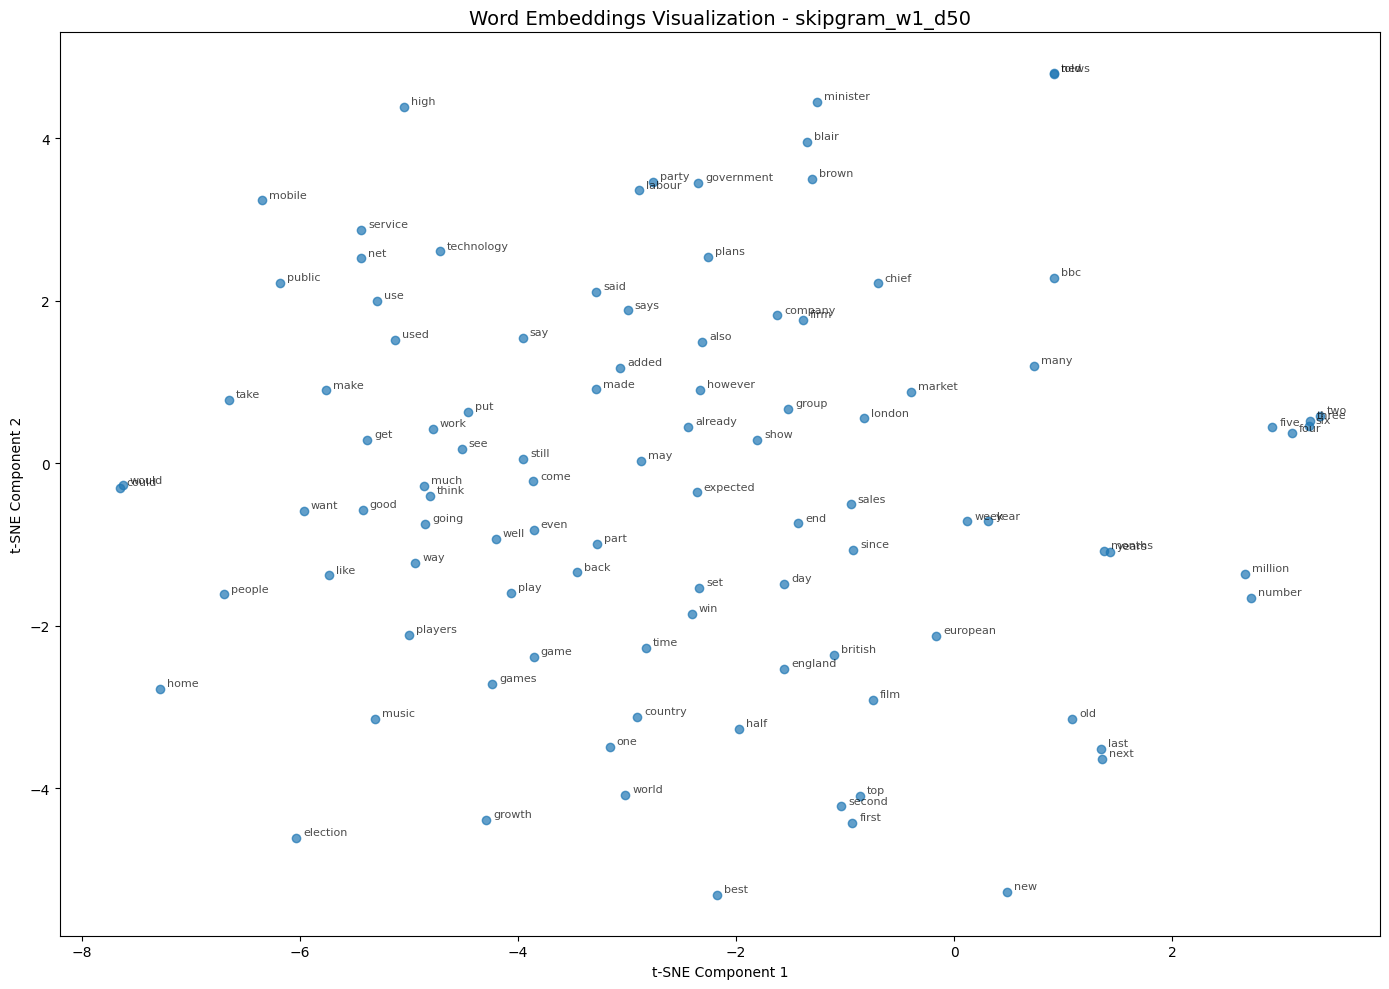

Visualisasi untuk model: skipgram_w1_d100


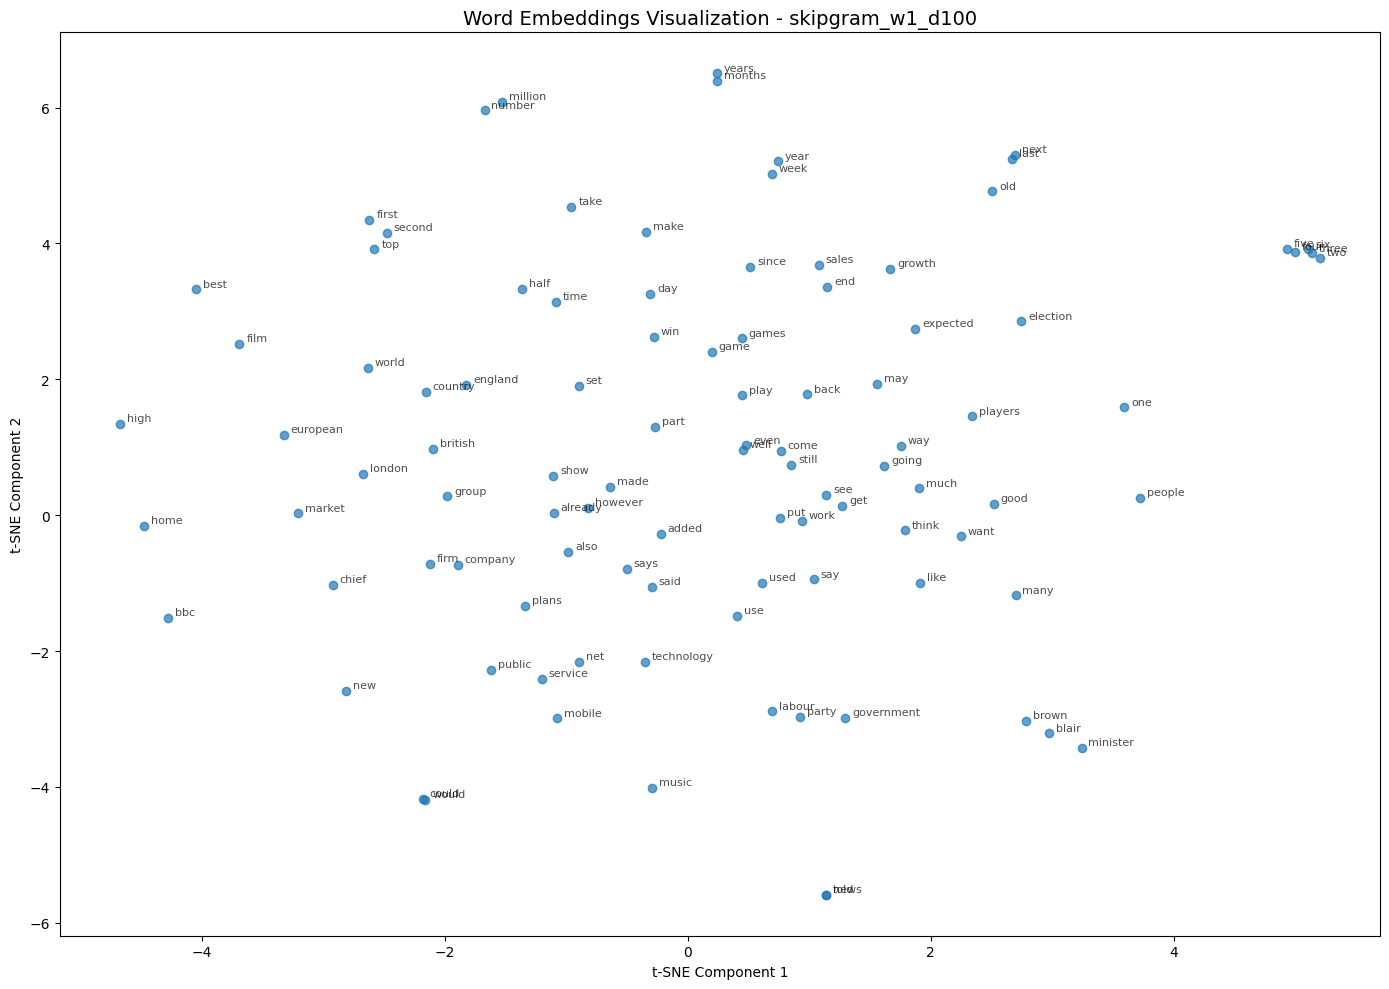

Visualisasi untuk model: skipgram_w1_d200


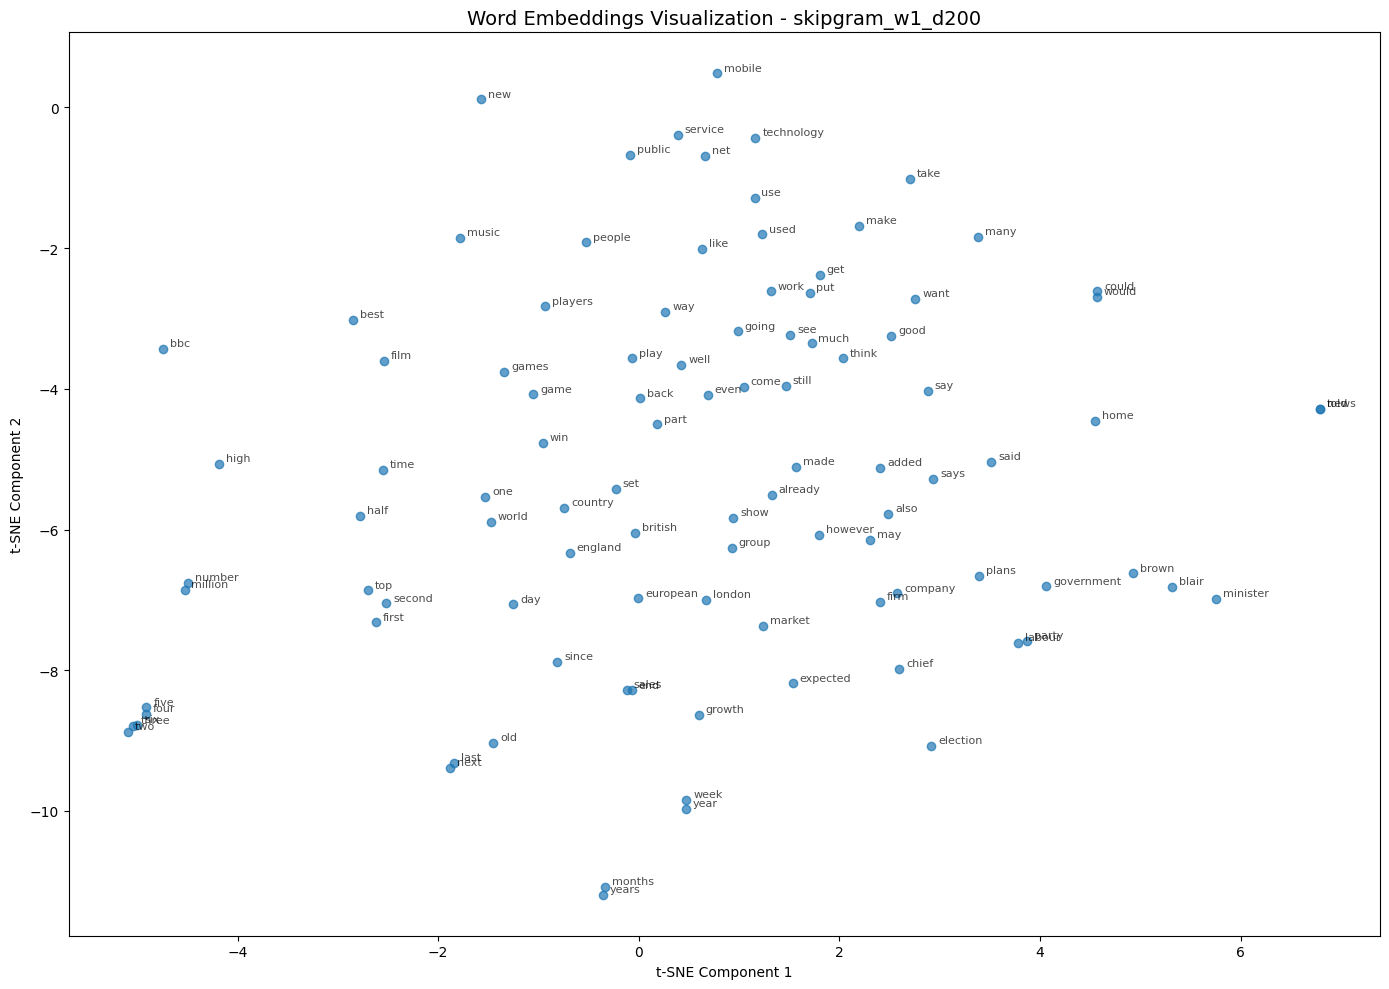

Visualisasi untuk model: skipgram_w2_d50


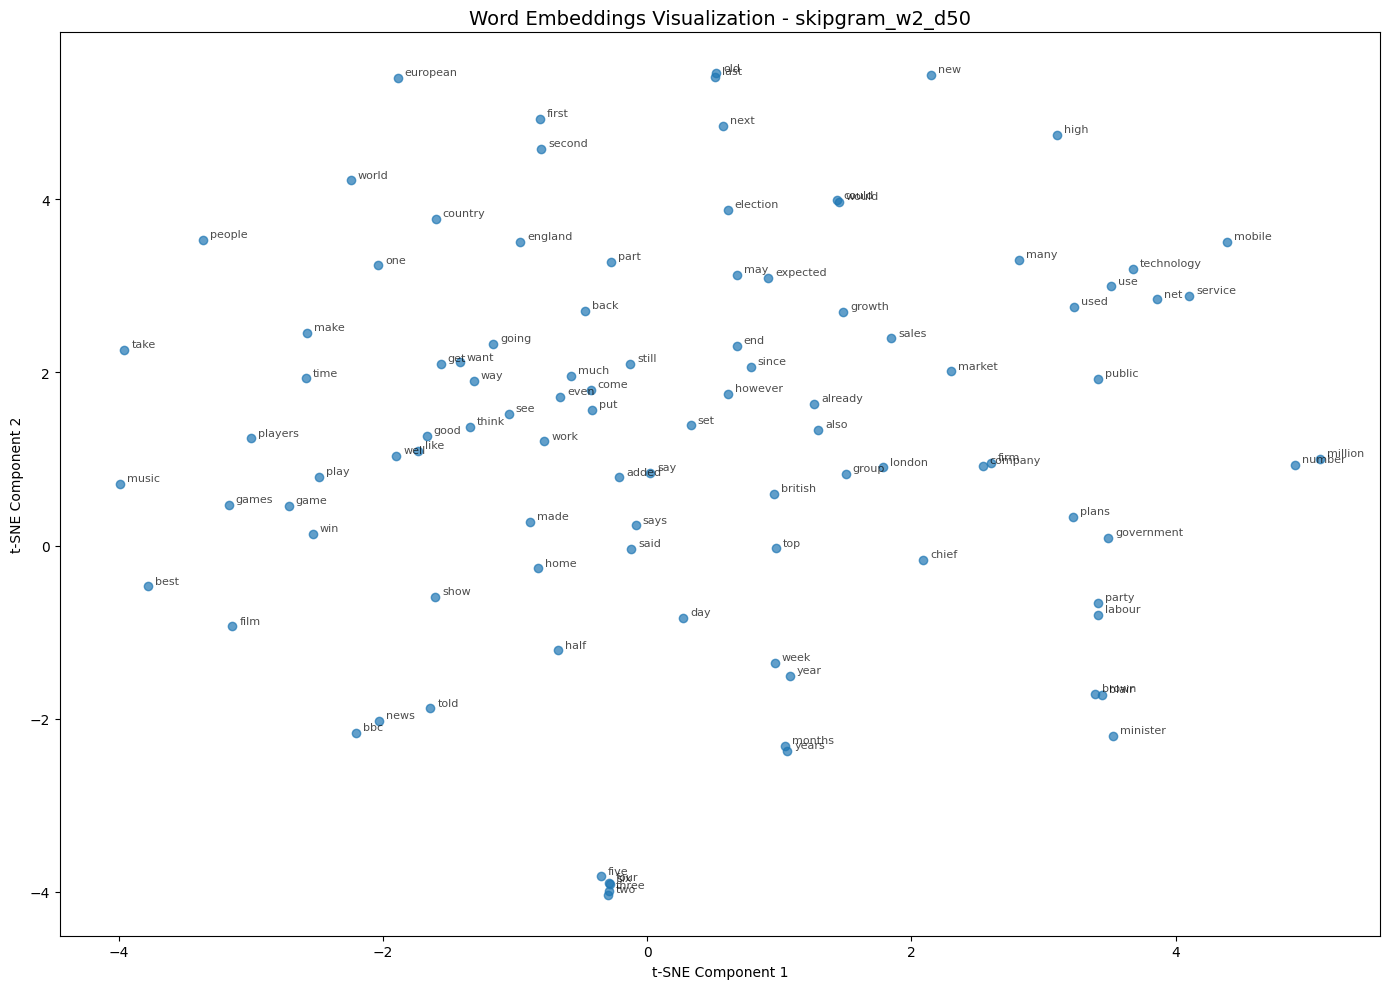

Visualisasi untuk model: skipgram_w2_d100


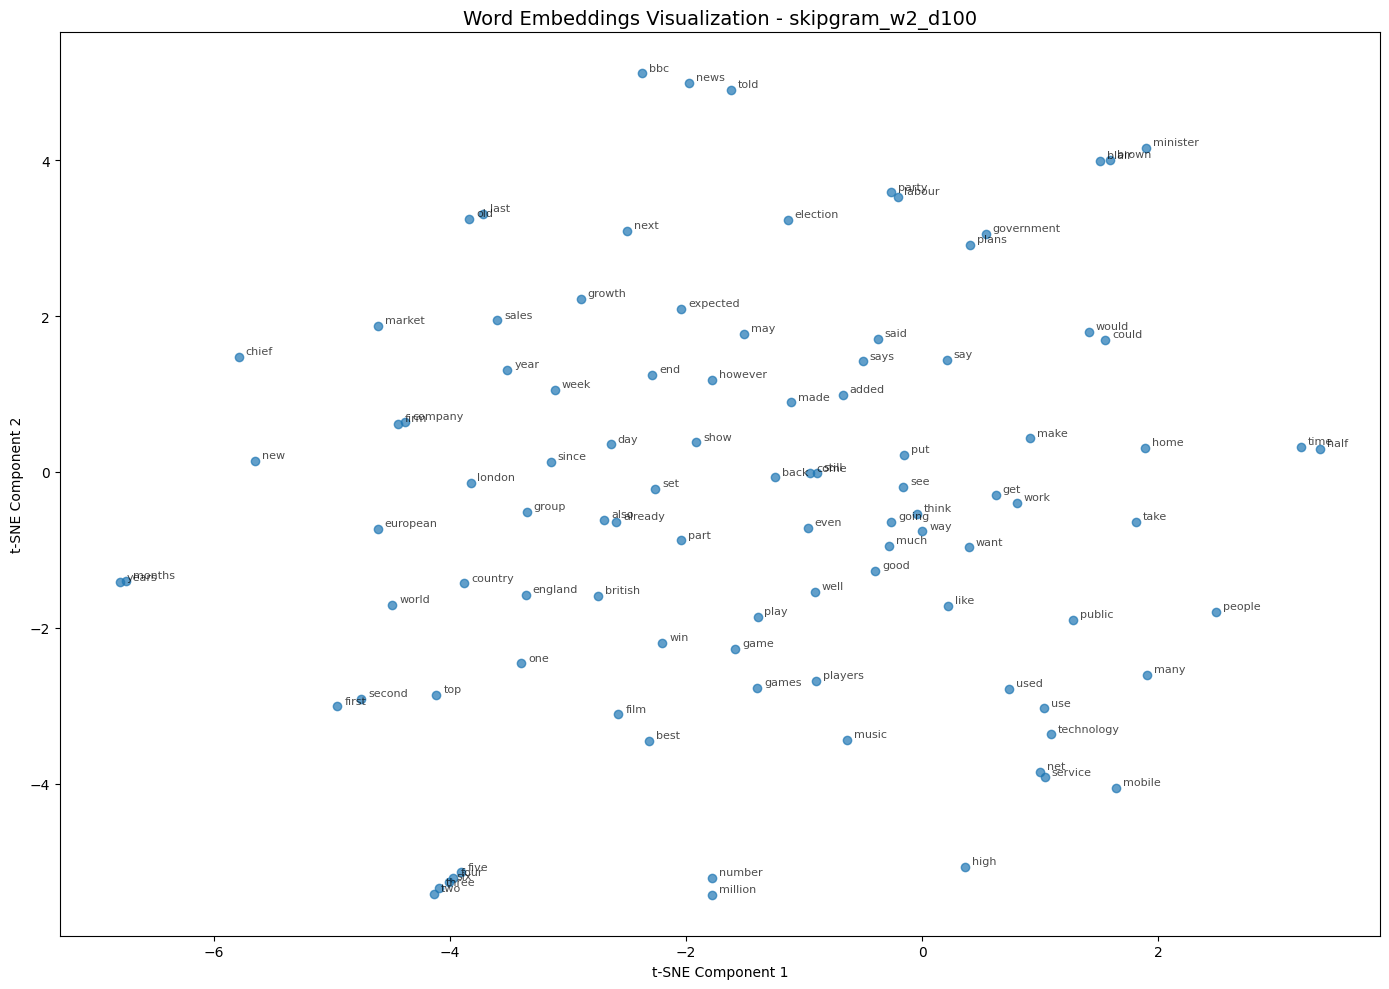

Visualisasi untuk model: skipgram_w2_d200


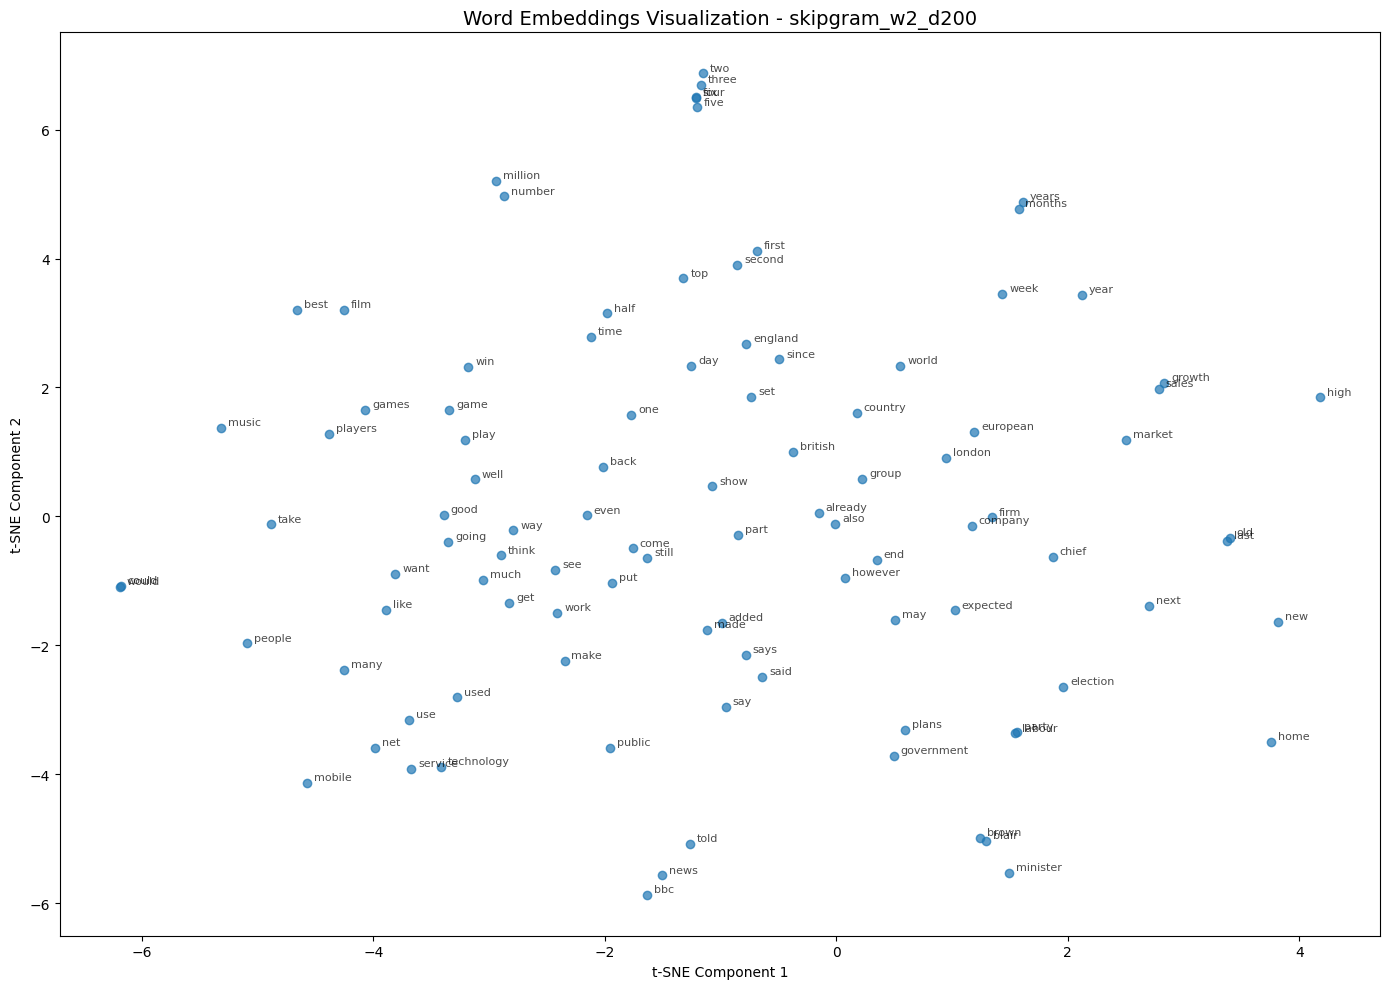

Visualisasi untuk model: skipgram_w3_d50


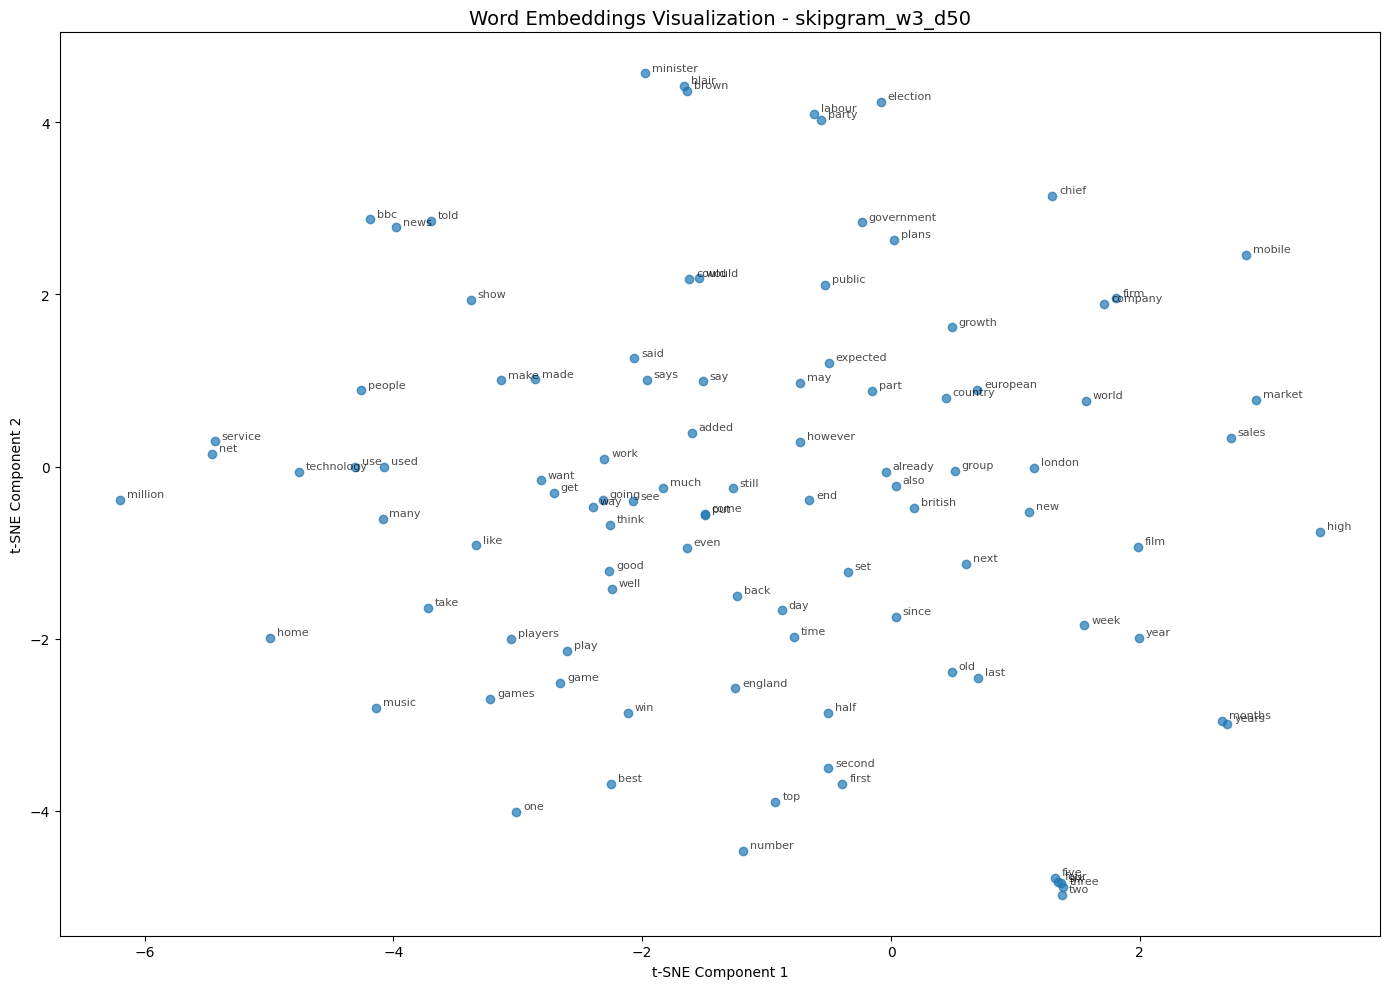

Visualisasi untuk model: skipgram_w3_d100


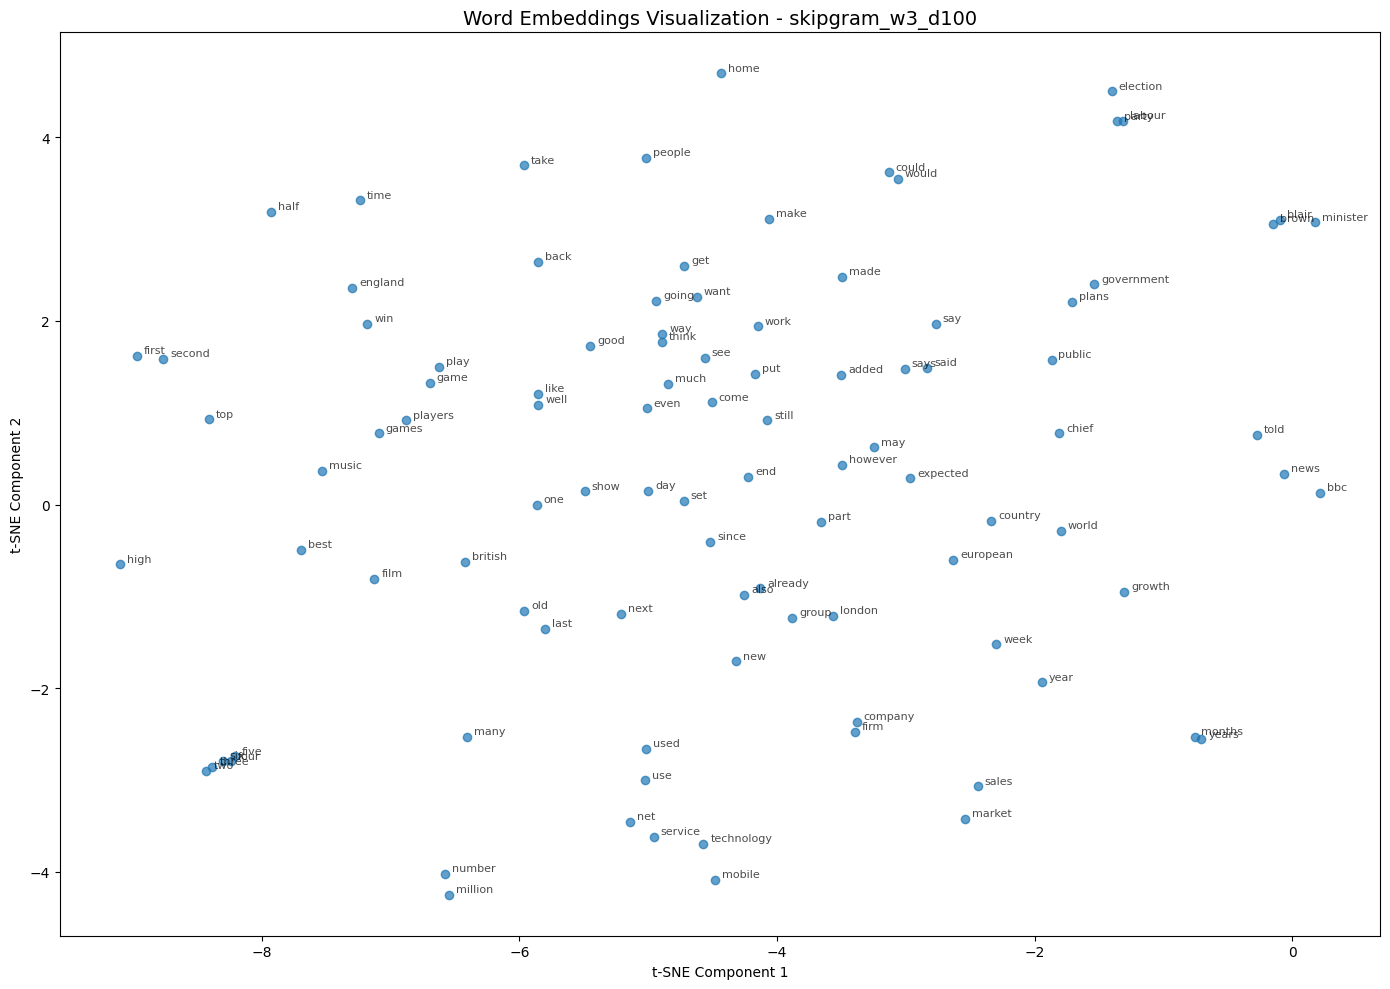

Visualisasi untuk model: skipgram_w3_d200


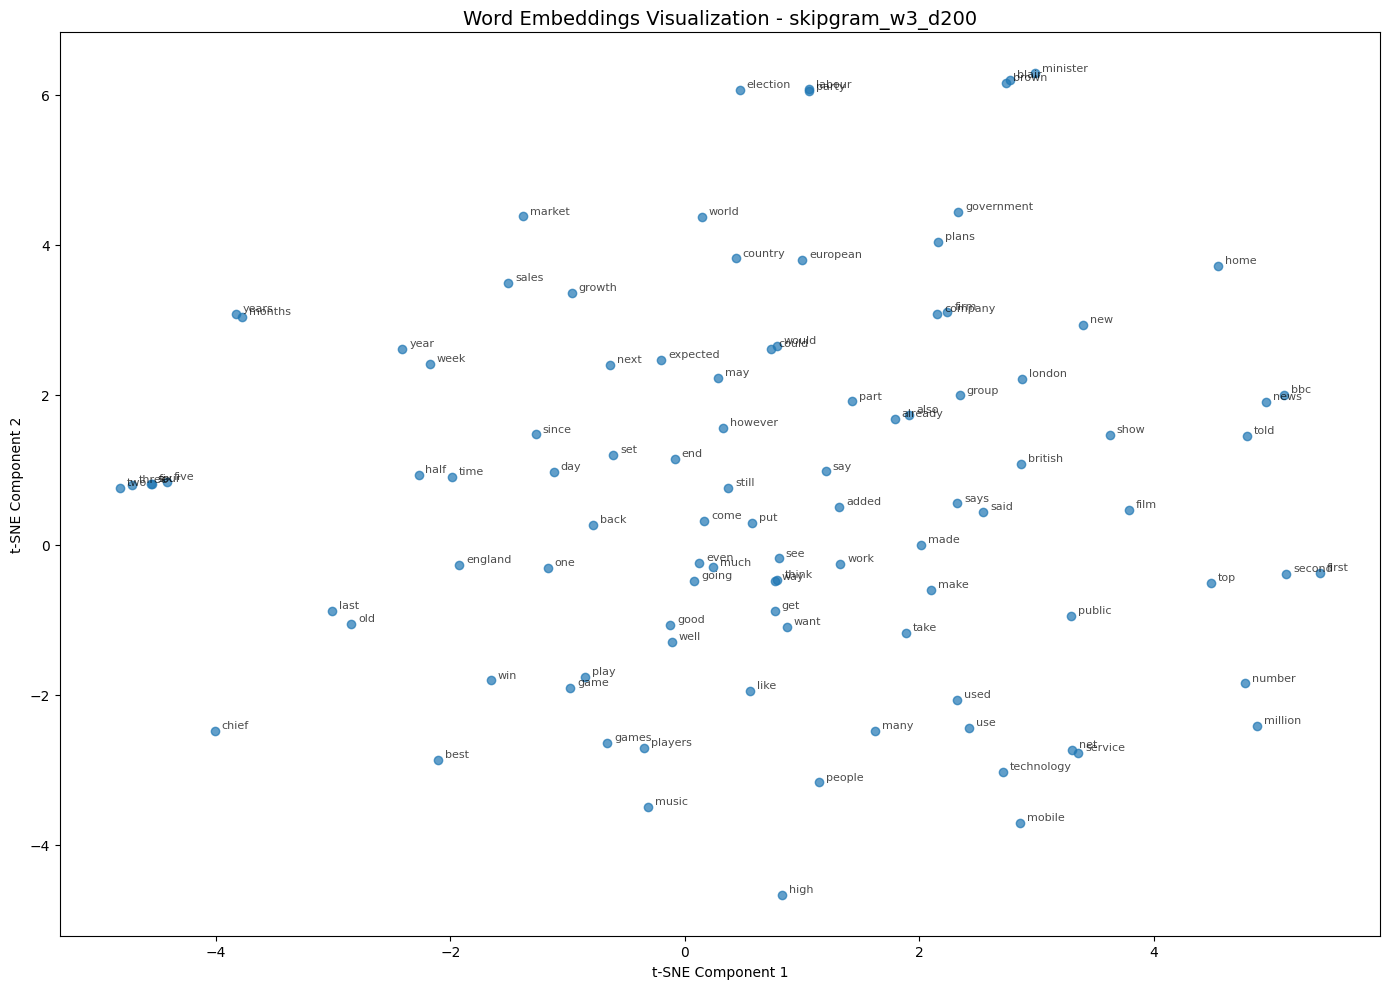

In [ ]:
# Function untuk membuat visualisasi t-SNE
def visualize_embeddings(model, model_name, num_words=100):
    # Mengambil kata dan vektor dari model
    words = list(model.wv.key_to_index.keys())[:num_words]
    word_vectors = np.array([model.wv[word] for word in words])

    # Melakukan dimensionality reduction dengan t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(word_vectors)

    # Visualisasi
    plt.figure(figsize=(14, 10))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7)

    # Menambahkan label kata
    for i, word in enumerate(words):
        plt.annotate(word, xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]),
                     xytext=(5, 2), textcoords='offset points',
                     fontsize=8, alpha=0.7)

    plt.title(f"Word Embeddings Visualization - {model_name}", fontsize=14)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.tight_layout()
    plt.show()

# Visualisasi untuk setiap model
for model_name, model in models.items():
    print(f"Visualisasi untuk model: {model_name}")
    visualize_embeddings(model, model_name)

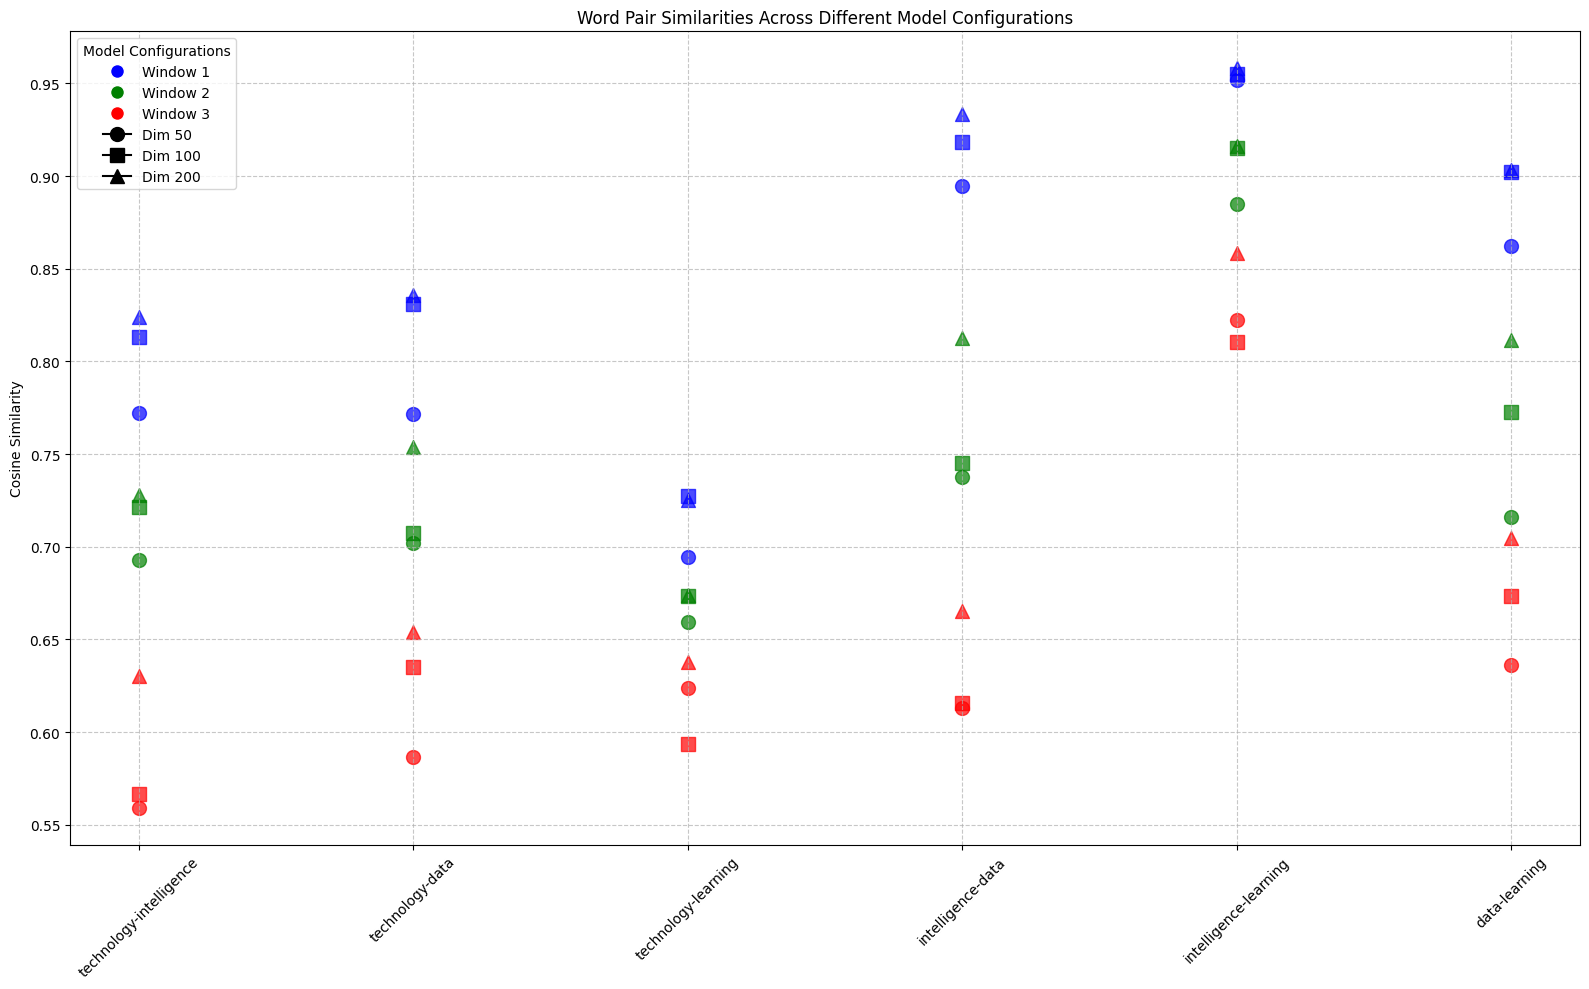

TypeError: DataFrame.pivot() takes 1 positional argument but 4 were given

<Figure size 1000x800 with 0 Axes>

In [ ]:
target_words = ['technology', 'intelligence', 'data', 'learning']

# Function untuk menghitung cosine similarity antara dua kata
def word_similarity(model, word1, word2):
    if word1 in model.wv and word2 in model.wv:
        return model.wv.similarity(word1, word2)
    return None

# Hitung similarity antar kata target untuk setiap model
similarity_results = {}

for model_name, model in models.items():
    pairs = []
    similarities = []

    for i in range(len(target_words)):
        for j in range(i+1, len(target_words)):
            word1 = target_words[i]
            word2 = target_words[j]

            sim = word_similarity(model, word1, word2)
            if sim is not None:
                pairs.append(f"{word1}-{word2}")
                similarities.append(sim)

    similarity_results[model_name] = {
        'pairs': pairs,
        'similarities': similarities
    }

# Visualisasi hasil
plt.figure(figsize=(16, 10))

window_colors = {1: 'blue', 2: 'green', 3: 'red'}
dim_markers = {50: 'o', 100: 's', 200: '^'}

for model_name, data in similarity_results.items():
    window = int(model_name.split('_w')[1].split('_')[0])
    dim = int(model_name.split('_d')[1])

    for pair_idx, pair in enumerate(data['pairs']):
        plt.scatter(pair_idx, data['similarities'][pair_idx],
                  color=window_colors[window], marker=dim_markers[dim],
                  s=100, alpha=0.7, label=model_name if pair_idx == 0 else "")

plt.xticks(range(len(data['pairs'])), data['pairs'], rotation=45)
plt.ylabel('Cosine Similarity')
plt.title('Word Pair Similarities Across Different Model Configurations')
plt.grid(True, linestyle='--', alpha=0.7)

# Creating a custom legend
handles = []
labels = []

# Legend for window sizes
for window, color in window_colors.items():
    handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'Window {window}'))
    labels.append(f'Window {window}')

# Legend for dimensions
for dim, marker in dim_markers.items():
    handles.append(plt.Line2D([0], [0], marker=marker, color='black', markersize=10, label=f'Dim {dim}'))
    labels.append(f'Dim {dim}')

plt.legend(handles=handles, labels=labels, title='Model Configurations', loc='best')
plt.tight_layout()
plt.show()

# Calculate average similarity by model configuration
avg_similarities = {}
for model_name, data in similarity_results.items():
    avg_similarities[model_name] = np.mean(data['similarities'])

# Create a DataFrame for analysis
config_df = pd.DataFrame({
    'model': list(avg_similarities.keys()),
    'avg_similarity': list(avg_similarities.values())
})
config_df['window'] = config_df['model'].apply(lambda x: int(x.split('_w')[1].split('_')[0]))
config_df['dimension'] = config_df['model'].apply(lambda x: int(x.split('_d')[1]))

# Plot heatmap
plt.figure(figsize=(10, 8))
pivot_df = config_df.pivot('window', 'dimension', 'avg_similarity')
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Average Word Similarity by Window Size and Embedding Dimension')
plt.xlabel('Embedding Dimension')
plt.ylabel('Window Size')
plt.tight_layout()
plt.show()

print("Analisis hasil:")
for window in sorted(config_df['window'].unique()):
    for dimension in sorted(config_df['dimension'].unique()):
        subset = config_df[(config_df['window'] == window) & (config_df['dimension'] == dimension)]
        model_name = subset['model'].values[0]
        avg_sim = subset['avg_similarity'].values[0]
        print(f"Model {model_name}: Window={window}, Dimension={dimension}, Avg Similarity={avg_sim:.4f}")


Analisis vektor untuk model: skipgram_w1_d50
                  mean       std       min       max      norm
technology   -0.057368  0.343526 -1.223251  0.591927  2.462732
intelligence -0.014759  0.226657 -0.657333  0.530510  1.606100
data         -0.024909  0.249641 -0.790407  0.507777  1.773994
learning     -0.015243  0.203837 -0.538321  0.510478  1.445368
computer     -0.022845  0.273196 -0.846738  0.520743  1.938526
network      -0.027014  0.233530 -0.742547  0.534218  1.662320
software     -0.013789  0.287543 -0.709242  0.538790  2.035576


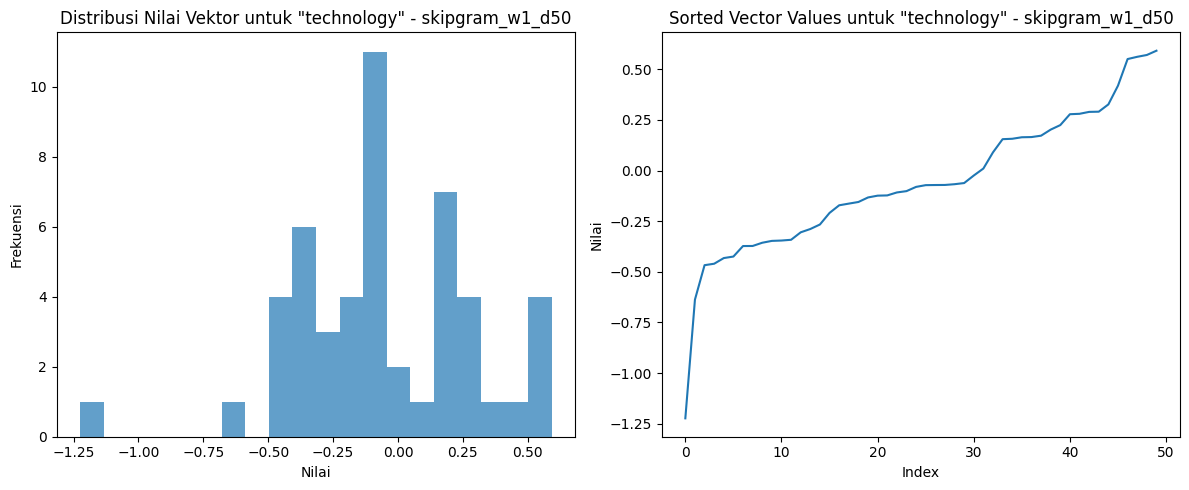


Analisis jarak cosine antar kata:


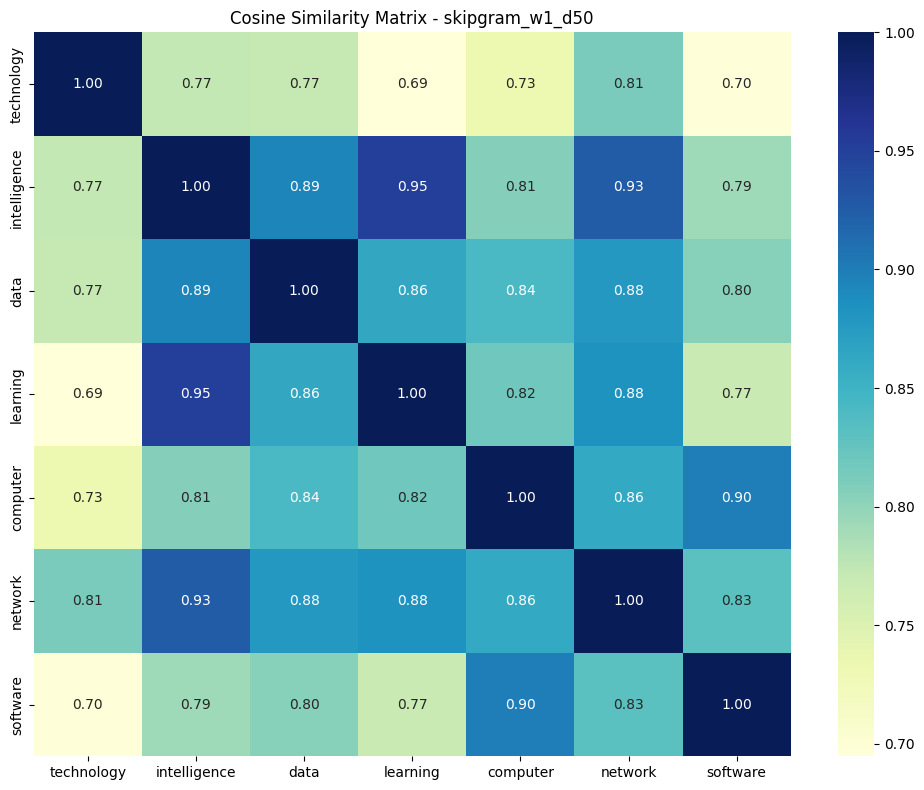


Analisis vektor untuk model: skipgram_w1_d100
                  mean       std       min       max      norm
technology   -0.026285  0.234620 -0.663779  0.567640  2.360878
intelligence -0.019568  0.159086 -0.584059  0.410740  1.602847
data         -0.017887  0.168882 -0.459833  0.430751  1.698267
learning     -0.017934  0.143977 -0.582383  0.362192  1.450892
computer     -0.037019  0.183656 -0.541810  0.473440  1.873502
network      -0.014178  0.162157 -0.590378  0.444882  1.627757
software     -0.043519  0.189008 -0.437722  0.456207  1.939528


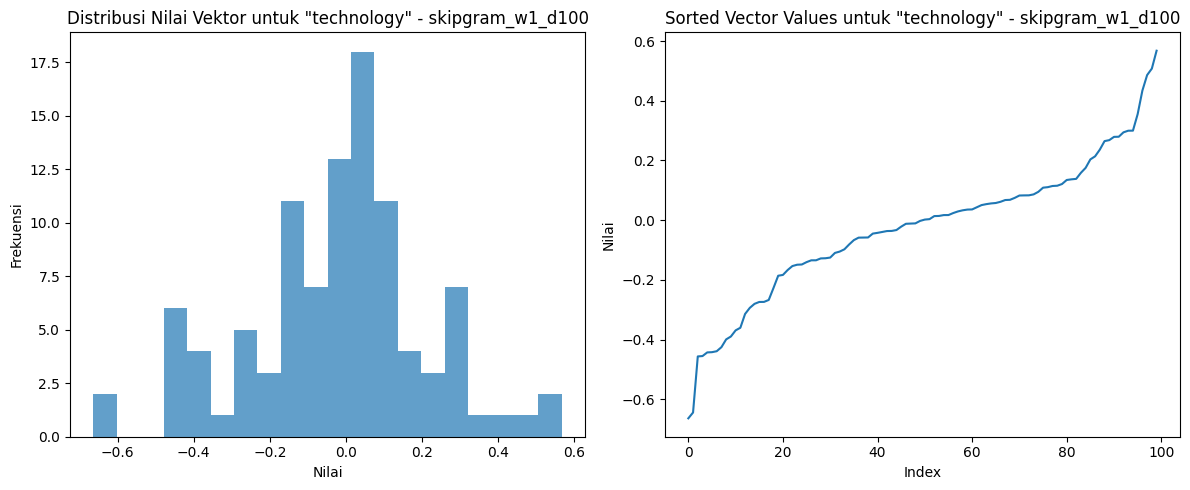


Analisis jarak cosine antar kata:


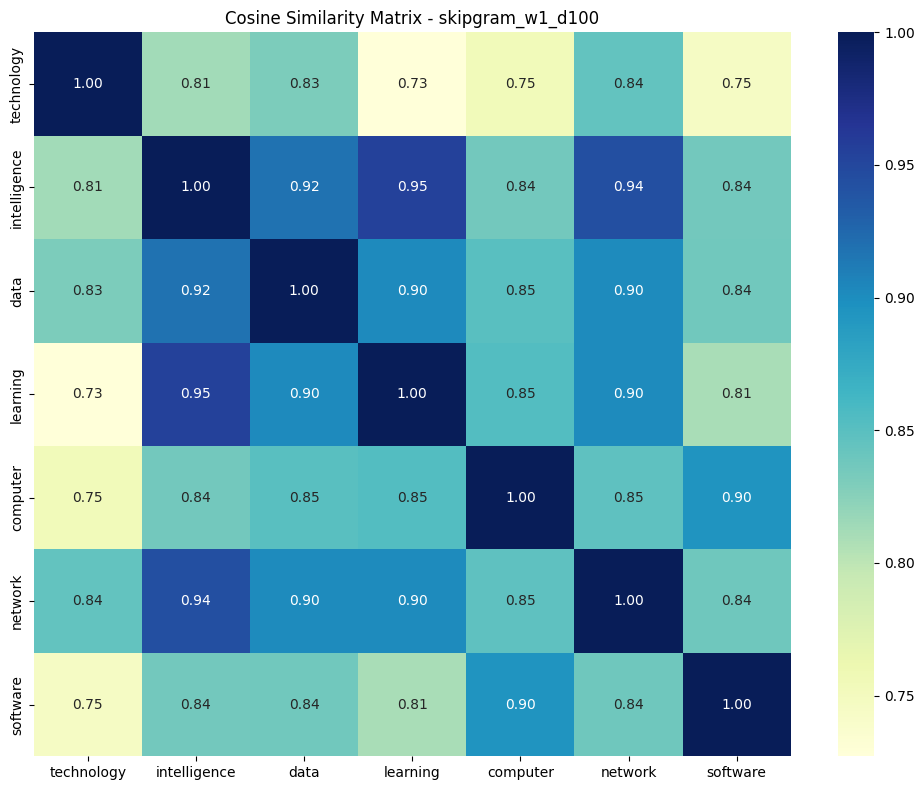


Analisis vektor untuk model: skipgram_w1_d200
                  mean       std       min       max      norm
technology   -0.012316  0.163759 -0.412522  0.501148  2.322449
intelligence -0.004727  0.113040 -0.368897  0.343649  1.600020
data         -0.008911  0.118859 -0.424551  0.360719  1.685636
learning     -0.004474  0.102435 -0.406059  0.322303  1.450030
computer     -0.007433  0.130035 -0.348778  0.427368  1.841979
network      -0.007252  0.113056 -0.286352  0.331797  1.602134
software     -0.011632  0.132472 -0.360688  0.432947  1.880644


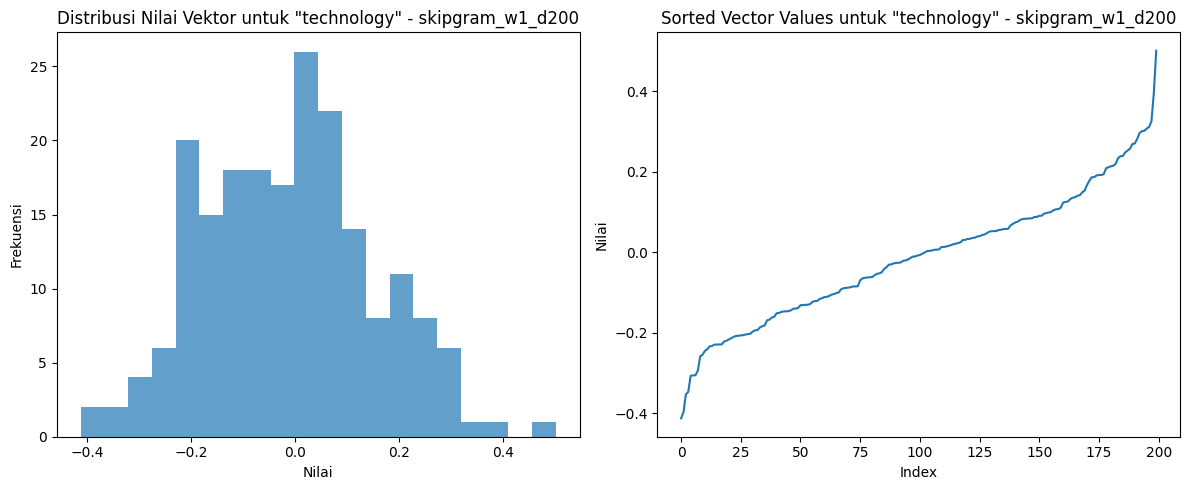


Analisis jarak cosine antar kata:


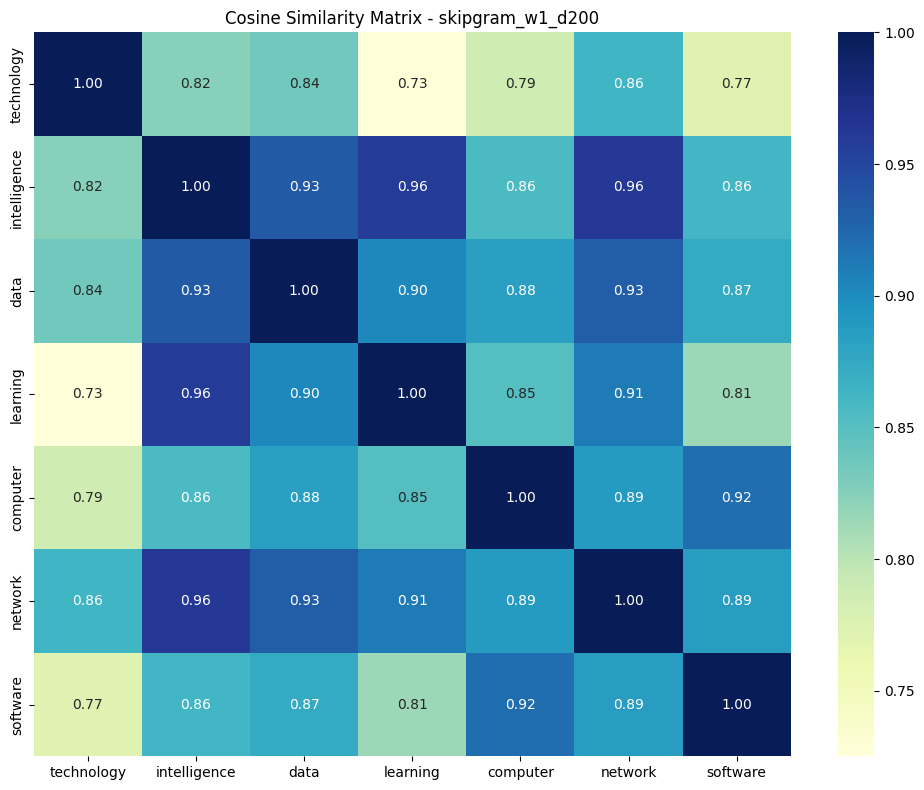


Analisis vektor untuk model: skipgram_w2_d50
                  mean       std       min       max      norm
technology   -0.007523  0.365921 -0.985209  1.000389  2.587998
intelligence -0.018308  0.227577 -0.666426  0.434176  1.614414
data         -0.024666  0.294412 -0.715494  0.806004  2.089097
learning     -0.025402  0.198712 -0.632221  0.453254  1.416538
computer     -0.033066  0.307827 -1.064020  0.541586  2.189190
network      -0.012086  0.256100 -0.663376  0.698346  1.812914
software     -0.034788  0.350252 -0.855398  0.701690  2.488843


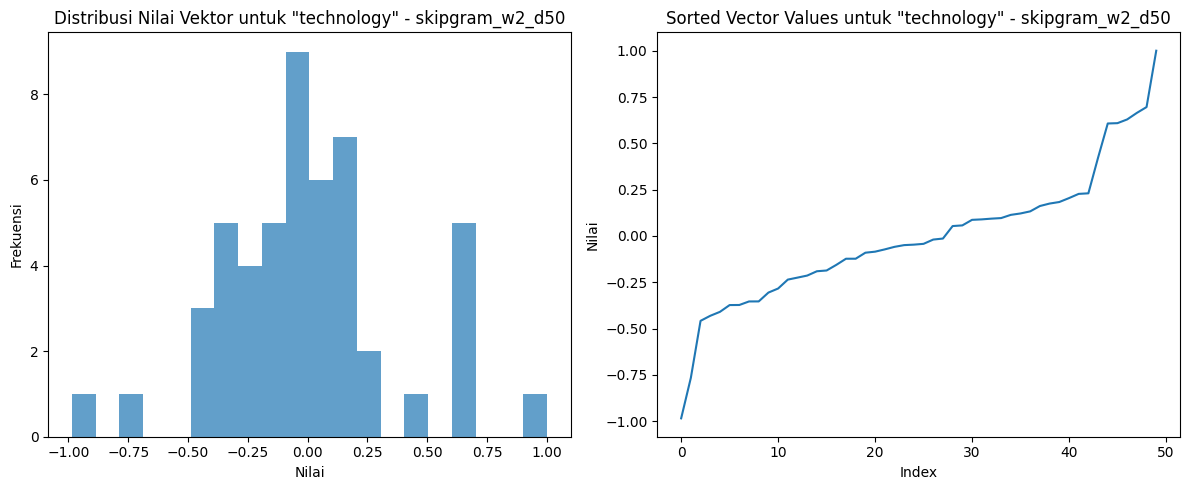


Analisis jarak cosine antar kata:


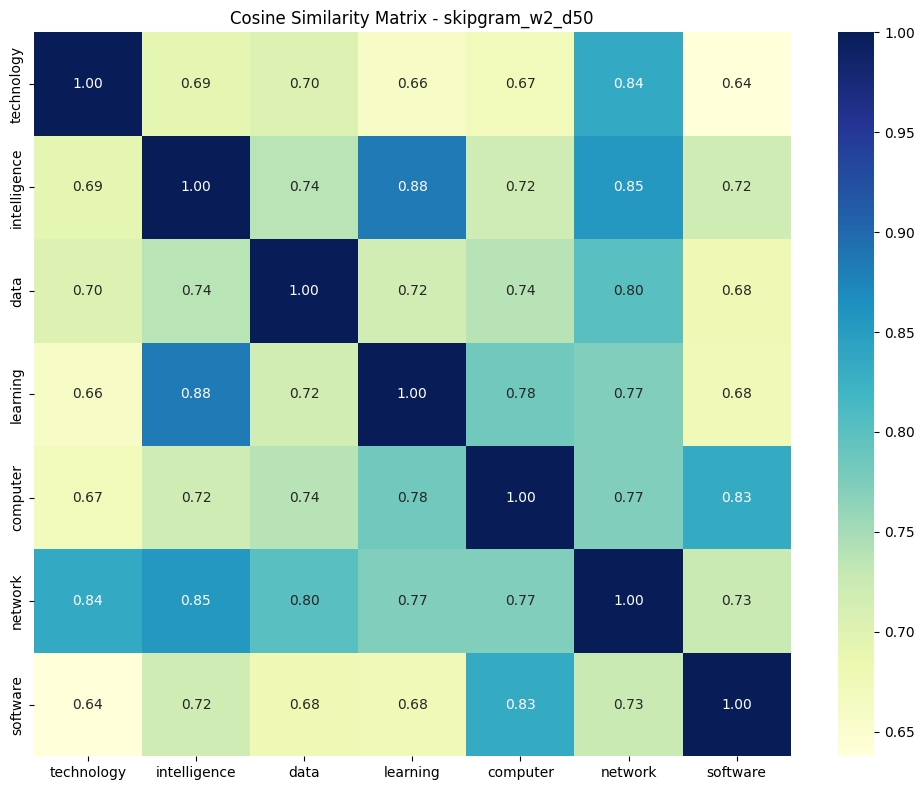


Analisis vektor untuk model: skipgram_w2_d100
                  mean       std       min       max      norm
technology   -0.029615  0.251364 -0.538766  0.738137  2.531031
intelligence -0.016012  0.160464 -0.574990  0.380248  1.612605
data         -0.023823  0.193223 -0.501751  0.524652  1.946861
learning     -0.014385  0.138221 -0.535628  0.319221  1.389672
computer     -0.021824  0.219904 -0.556008  0.474384  2.209842
network      -0.010092  0.180947 -0.556317  0.517978  1.812280
software     -0.029982  0.241009 -0.560593  0.551543  2.428669


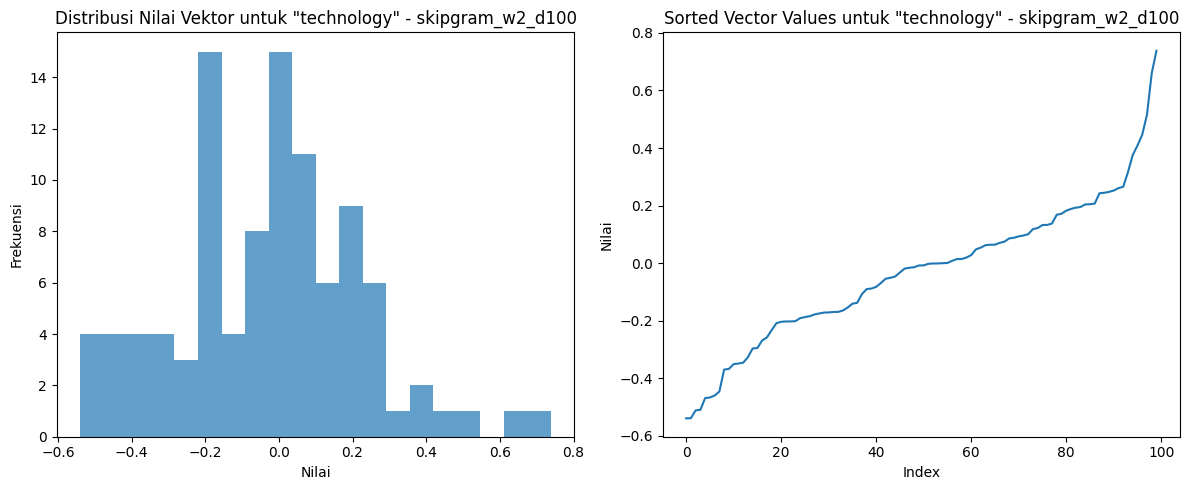


Analisis jarak cosine antar kata:


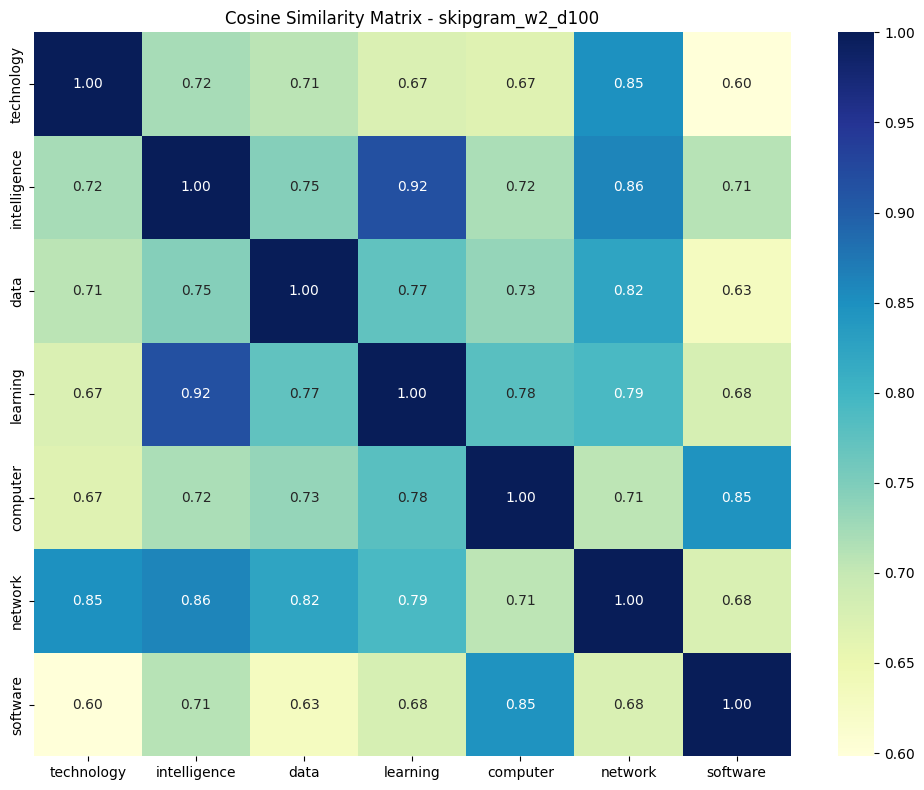


Analisis vektor untuk model: skipgram_w2_d200
                  mean       std       min       max      norm
technology   -0.012532  0.174884 -0.504977  0.542727  2.479580
intelligence -0.003877  0.111950 -0.359366  0.350856  1.584166
data         -0.011437  0.127399 -0.384074  0.379449  1.808940
learning     -0.002058  0.098182 -0.372634  0.277990  1.388802
computer      0.002166  0.155394 -0.355113  0.457919  2.197817
network      -0.009198  0.118836 -0.299092  0.382528  1.685623
software     -0.005041  0.165825 -0.416425  0.509810  2.346196


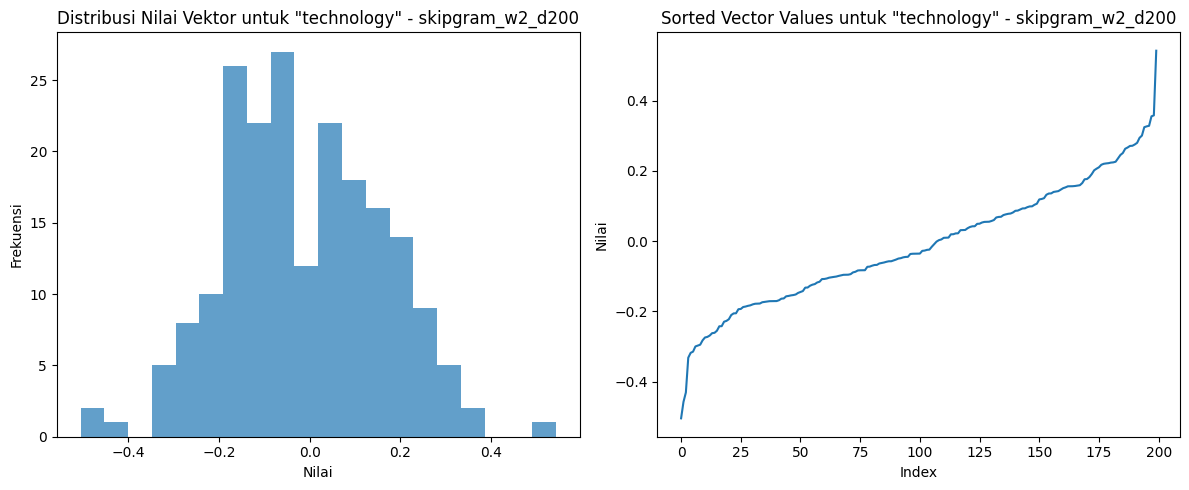


Analisis jarak cosine antar kata:


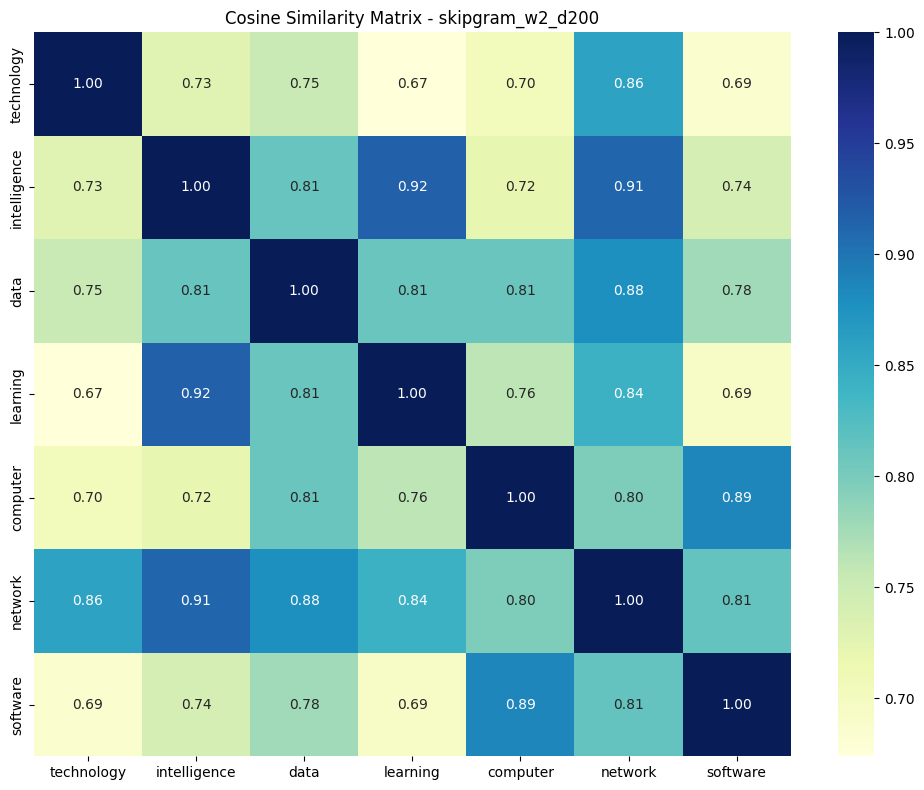


Analisis vektor untuk model: skipgram_w3_d50
                  mean       std       min       max      norm
technology   -0.037383  0.397123 -1.174426  0.901747  2.820501
intelligence -0.011022  0.235580 -0.594065  0.471789  1.667625
data         -0.009705  0.334912 -0.711341  0.835177  2.369181
learning     -0.019982  0.198798 -0.593652  0.414399  1.412796
computer     -0.030532  0.339205 -1.000951  0.622191  2.408237
network      -0.019993  0.285413 -0.701645  0.792279  2.023123
software      0.022916  0.404460 -0.900167  1.134297  2.864554


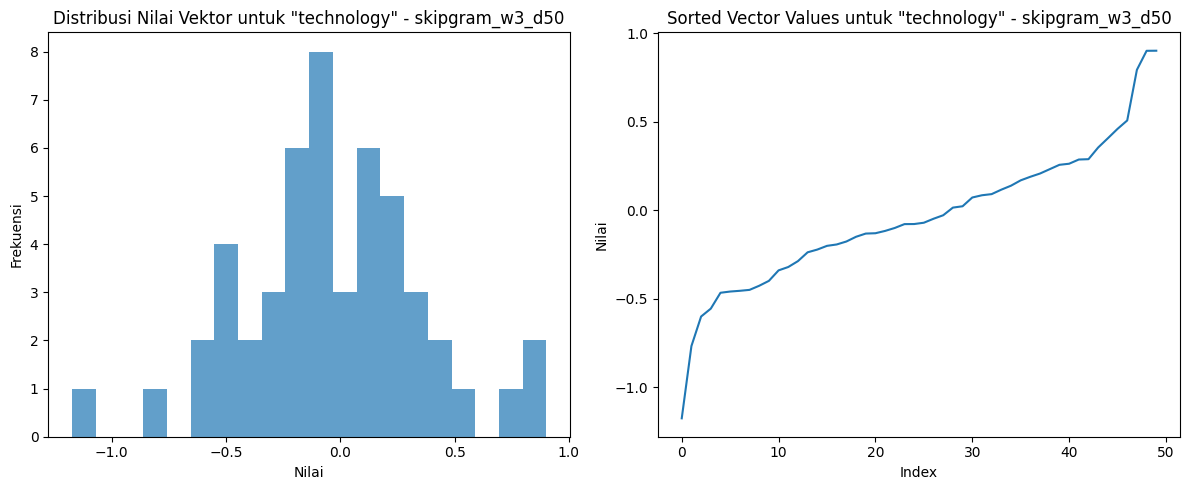


Analisis jarak cosine antar kata:


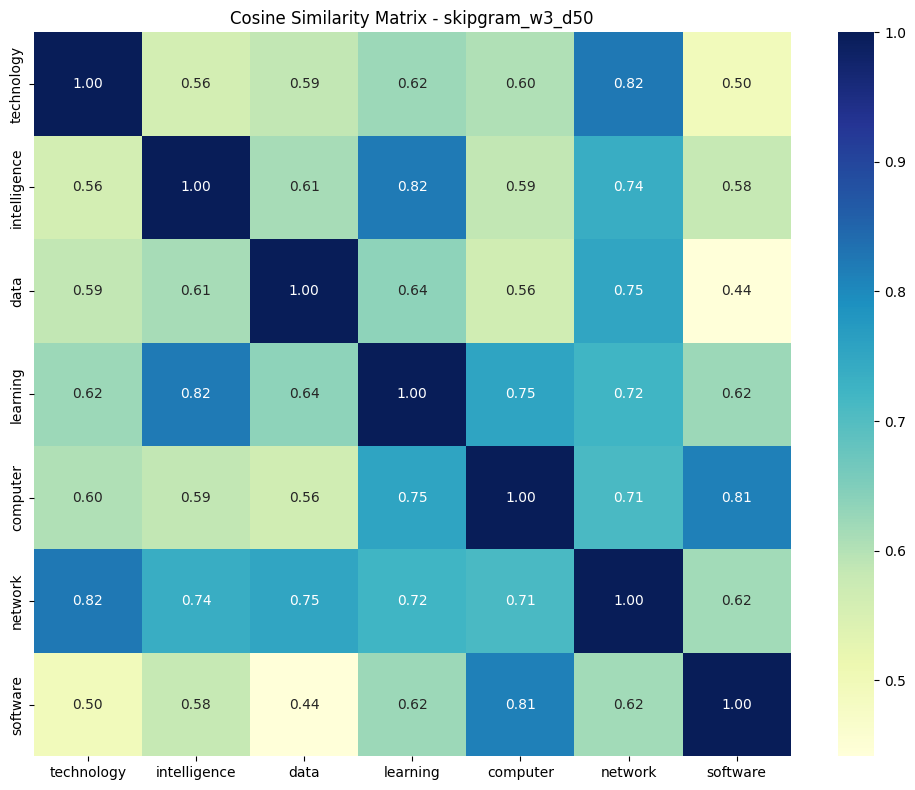


Analisis vektor untuk model: skipgram_w3_d100
                  mean       std       min       max      norm
technology   -0.026425  0.283841 -0.964827  0.637131  2.850682
intelligence -0.020432  0.162214 -0.655571  0.381776  1.634960
data         -0.020089  0.216006 -0.522017  0.671181  2.169381
learning     -0.010873  0.142269 -0.544786  0.352629  1.426840
computer     -0.016801  0.236169 -0.633047  0.516214  2.367657
network      -0.013378  0.188112 -0.647181  0.492166  1.885872
software     -0.029340  0.263902 -0.623921  0.612723  2.655276


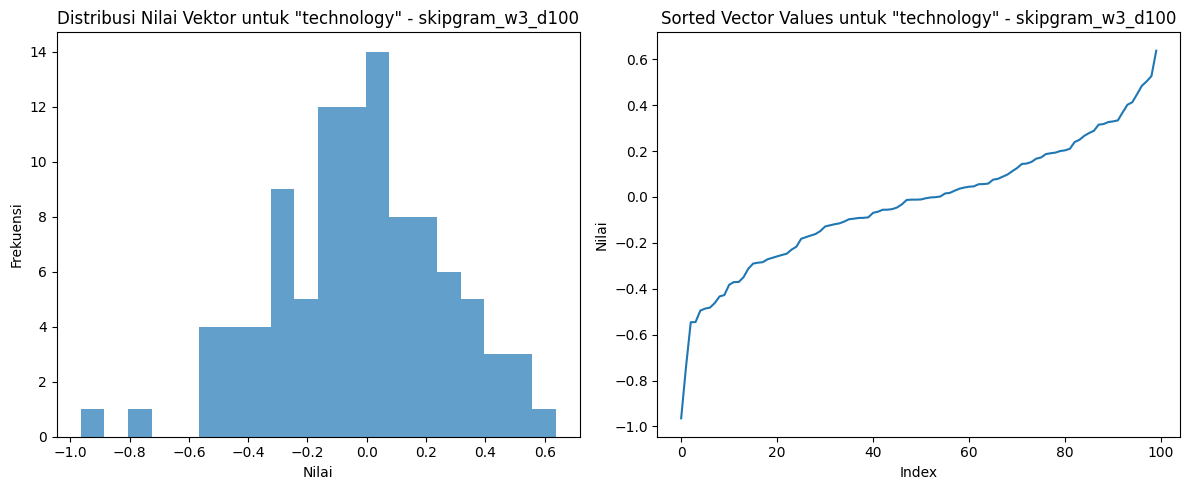


Analisis jarak cosine antar kata:


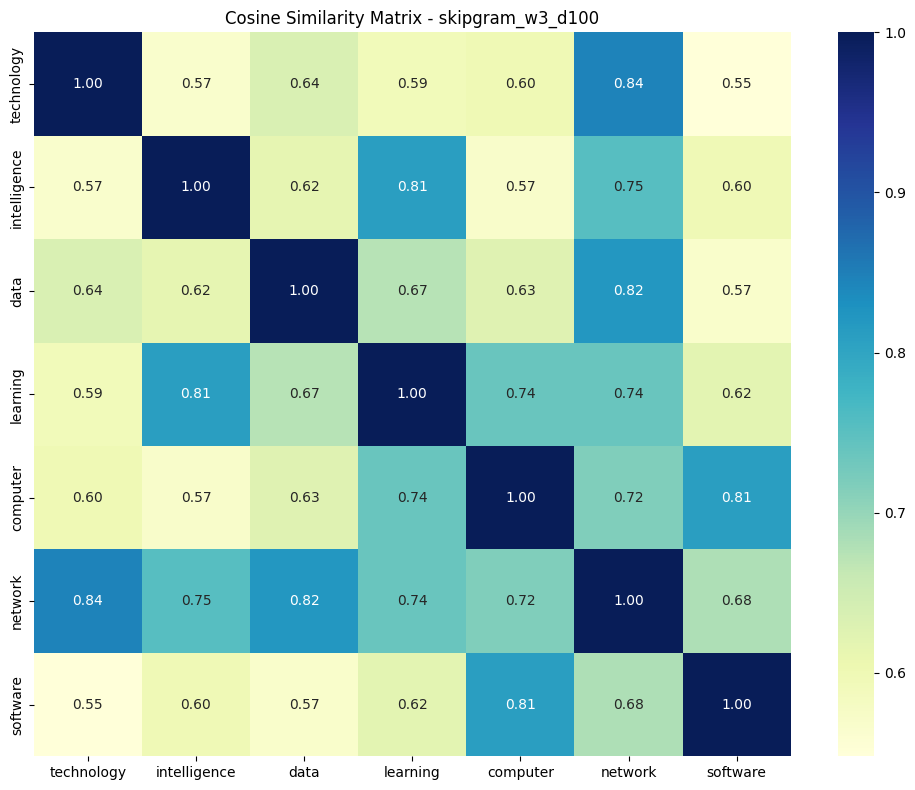


Analisis vektor untuk model: skipgram_w3_d200
                  mean       std       min       max      norm
technology   -0.018963  0.183307 -0.625717  0.400348  2.606183
intelligence -0.005365  0.117234 -0.371063  0.346846  1.659679
data         -0.024167  0.150552 -0.382144  0.403830  2.156389
learning     -0.001594  0.100229 -0.366624  0.273144  1.417637
computer     -0.002890  0.163807 -0.354716  0.441461  2.316938
network      -0.012230  0.127981 -0.314655  0.365250  1.818165
software     -0.009909  0.188540 -0.437128  0.592623  2.670038


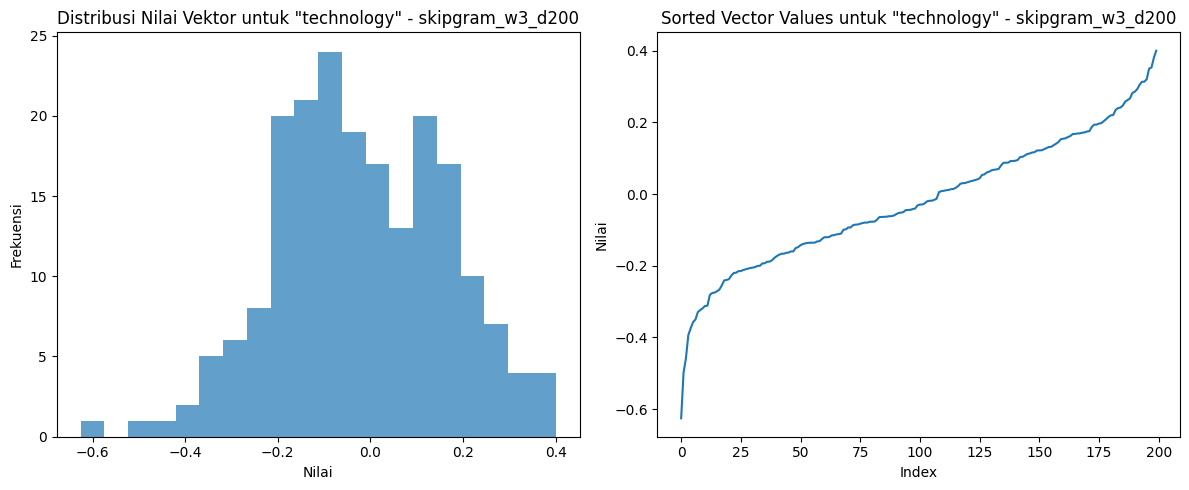


Analisis jarak cosine antar kata:


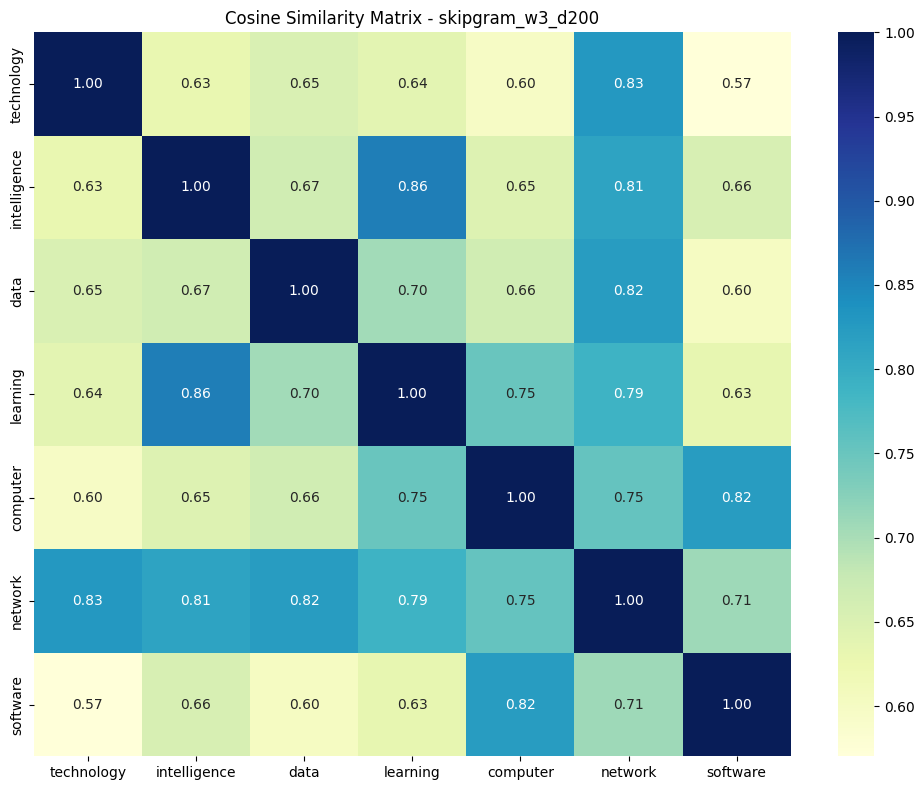

In [ ]:
# Analisis distribusi nilai vektor untuk beberapa kata penting
important_words = ['technology', 'intelligence', 'data', 'learning', 'computer', 'network', 'software']

# Fungsi untuk menganalisis vektor kata
def analyze_word_vectors(models, words):
    for model_name, model in models.items():
        print(f"\nAnalisis vektor untuk model: {model_name}")

        word_stats = {}

        for word in words:
            if word in model.wv:
                vector = model.wv[word]
                word_stats[word] = {
                    'mean': np.mean(vector),
                    'std': np.std(vector),
                    'min': np.min(vector),
                    'max': np.max(vector),
                    'norm': np.linalg.norm(vector)
                }

        # Menampilkan statistik
        stats_df = pd.DataFrame.from_dict(word_stats, orient='index')
        print(stats_df)

        # Plot distribusi nilai vektor untuk kata pertama (jika ada dalam model)
        for word in words:
            if word in model.wv:
                plt.figure(figsize=(12, 5))
                vector = model.wv[word]

                plt.subplot(1, 2, 1)
                plt.hist(vector, bins=20, alpha=0.7)
                plt.title(f'Distribusi Nilai Vektor untuk "{word}" - {model_name}')
                plt.xlabel('Nilai')
                plt.ylabel('Frekuensi')

                plt.subplot(1, 2, 2)
                plt.plot(range(len(vector)), sorted(vector))
                plt.title(f'Sorted Vector Values untuk "{word}" - {model_name}')
                plt.xlabel('Index')
                plt.ylabel('Nilai')

                plt.tight_layout()
                plt.show()

                # Hanya tampilkan untuk kata pertama yang ditemukan
                break

        # Analisis jarak antar kata
        print("\nAnalisis jarak cosine antar kata:")
        cosine_df = pd.DataFrame(index=words, columns=words)

        for word1 in words:
            for word2 in words:
                if word1 in model.wv and word2 in model.wv:
                    cosine_df.loc[word1, word2] = model.wv.similarity(word1, word2)

        plt.figure(figsize=(10, 8))
        sns.heatmap(cosine_df.astype(float), annot=True, cmap='YlGnBu', fmt='.2f')
        plt.title(f'Cosine Similarity Matrix - {model_name}')
        plt.tight_layout()
        plt.show()

        print("=" * 80)

# Analisis representasi vektor
analyze_word_vectors(models, important_words)

<ipython-input-55-f987ddb9a292>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='avg_similarity', data=metrics_df, ax=axes[0], palette='viridis')
<ipython-input-55-f987ddb9a292>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='memory_mb', data=metrics_df, ax=axes[1], palette='viridis')


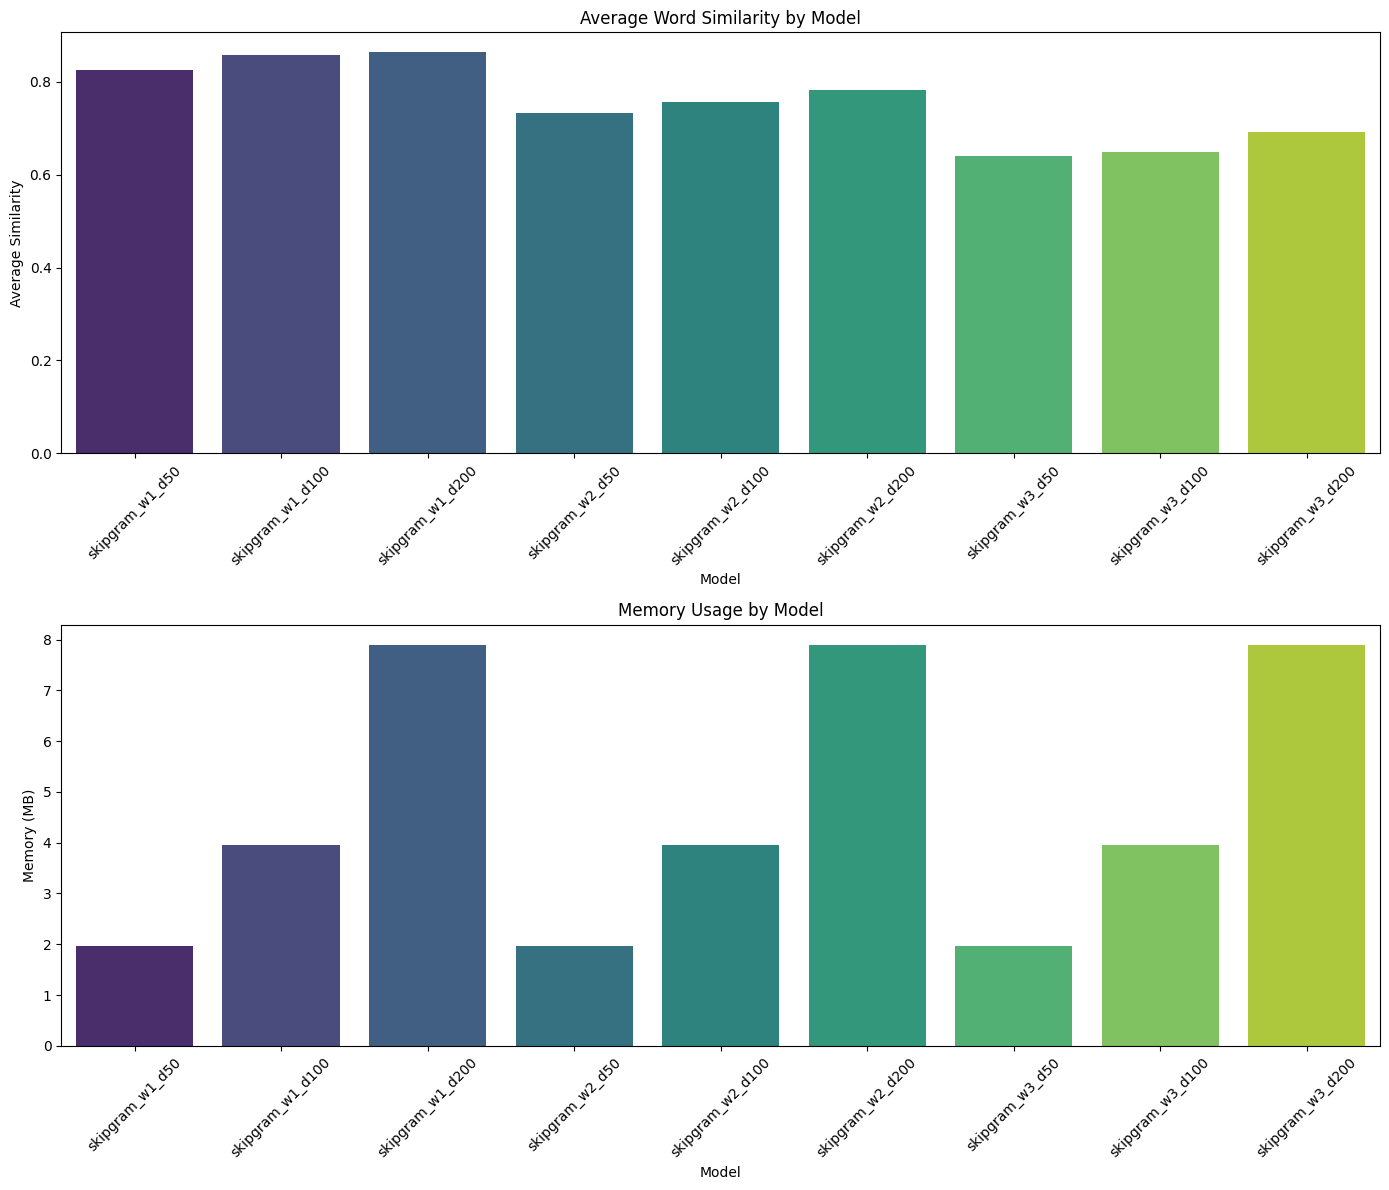

KESIMPULAN ANALISIS MODEL SKIP-GRAM:
--------------------------------------------------------------------------------
1. Model dengan similarity tertinggi: skipgram_w1_d200 (Window=1, Dimension=200)
2. Window size terbaik secara rata-rata: 1.0
   Pengaruh window size:
   - Window 1.0: Avg Similarity = 0.8486
   - Window 2.0: Avg Similarity = 0.7570
   - Window 3.0: Avg Similarity = 0.6603
3. Dimensi embedding terbaik secara rata-rata: 200.0
   Pengaruh dimensi embedding:
   - Dimension 50.0: Avg Similarity = 0.7323
   - Dimension 100.0: Avg Similarity = 0.7543
   - Dimension 200.0: Avg Similarity = 0.7793

4. Trade-off antara penggunaan memori dan kualitas model:
   - skipgram_w1_d50: Memory=1.97MB, Similarity=0.8246
   - skipgram_w1_d100: Memory=3.95MB, Similarity=0.8579
   - skipgram_w1_d200: Memory=7.89MB, Similarity=0.8634
   - skipgram_w2_d50: Memory=1.97MB, Similarity=0.7322
   - skipgram_w2_d100: Memory=3.95MB, Similarity=0.7560
   - skipgram_w2_d200: Memory=7.89MB, Similarity=0

In [ ]:
# Mengumpulkan metrik dari semua model untuk perbandingan
model_metrics = {}

for model_name, model in models.items():
    window = int(model_name.split('_w')[1].split('_')[0])
    dim = int(model_name.split('_d')[1])

    # Vocabulary size
    vocab_size = len(model.wv.key_to_index)

    # Rata-rata similarity dari hasil sebelumnya
    avg_sim = config_df[(config_df['window'] == window) & (config_df['dimension'] == dim)]['avg_similarity'].values[0]

    # Memory usage
    memory_mb = model.wv.vectors.nbytes / (1024 * 1024)

    model_metrics[model_name] = {
        'window': window,
        'dimension': dim,
        'vocab_size': vocab_size,
        'avg_similarity': avg_sim,
        'memory_mb': memory_mb
    }

# Membuat DataFrame untuk visualisasi perbandingan
metrics_df = pd.DataFrame.from_dict(model_metrics, orient='index')
metrics_df = metrics_df.reset_index().rename(columns={'index': 'model'})

# Plot perbandingan
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Bar plot untuk rata-rata similarity
sns.barplot(x='model', y='avg_similarity', data=metrics_df, ax=axes[0], palette='viridis')
axes[0].set_title('Average Word Similarity by Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Average Similarity')
for tick in axes[0].get_xticklabels():
    tick.set_rotation(45)

# Bar plot untuk penggunaan memori
sns.barplot(x='model', y='memory_mb', data=metrics_df, ax=axes[1], palette='viridis')
axes[1].set_title('Memory Usage by Model')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Memory (MB)')
for tick in axes[1].get_xticklabels():
    tick.set_rotation(45)

plt.tight_layout()
plt.show()

# Kesimpulan
print("KESIMPULAN ANALISIS MODEL SKIP-GRAM:")
print("-" * 80)

# Temukan model dengan similarity tertinggi
best_sim_model = metrics_df.loc[metrics_df['avg_similarity'].idxmax()]['model']
best_sim_window = metrics_df.loc[metrics_df['avg_similarity'].idxmax()]['window']
best_sim_dim = metrics_df.loc[metrics_df['avg_similarity'].idxmax()]['dimension']

print(f"1. Model dengan similarity tertinggi: {best_sim_model} (Window={best_sim_window}, Dimension={best_sim_dim})")

# Analisis pengaruh window size
window_analysis = metrics_df.groupby('window')['avg_similarity'].mean().reset_index()
best_window = window_analysis.loc[window_analysis['avg_similarity'].idxmax()]['window']
print(f"2. Window size terbaik secara rata-rata: {best_window}")
print("   Pengaruh window size:")
for _, row in window_analysis.iterrows():
    print(f"   - Window {row['window']}: Avg Similarity = {row['avg_similarity']:.4f}")

# Analisis pengaruh dimensi
dim_analysis = metrics_df.groupby('dimension')['avg_similarity'].mean().reset_index()
best_dim = dim_analysis.loc[dim_analysis['avg_similarity'].idxmax()]['dimension']
print(f"3. Dimensi embedding terbaik secara rata-rata: {best_dim}")
print("   Pengaruh dimensi embedding:")
for _, row in dim_analysis.iterrows():
    print(f"   - Dimension {row['dimension']}: Avg Similarity = {row['avg_similarity']:.4f}")

# Trade-off memori vs kualitas
print("\n4. Trade-off antara penggunaan memori dan kualitas model:")
for _, row in metrics_df.iterrows():
    print(f"   - {row['model']}: Memory={row['memory_mb']:.2f}MB, Similarity={row['avg_similarity']:.4f}")

print("\n5. Rekomendasi model:")
# Memilih model berdasarkan keseimbangan memori dan kualitas
metrics_df['score'] = metrics_df['avg_similarity'] / (np.log1p(metrics_df['memory_mb']))
best_balanced_model = metrics_df.loc[metrics_df['score'].idxmax()]
print(f"   Model yang direkomendasikan: {best_balanced_model['model']}")
print(f"   Window Size: {best_balanced_model['window']}")
print(f"   Embedding Dimension: {best_balanced_model['dimension']}")
print(f"   Alasan: Keseimbangan terbaik antara kualitas representasi kata (similarity={best_balanced_model['avg_similarity']:.4f}) dan penggunaan memori ({best_balanced_model['memory_mb']:.2f}MB)")